# Evaluacion parcial 2 — Sistema VIP con Machine Learning

Este notebook desarrolla una solución de Machine Learning aplicada a un problema de negocio: **segmentar clientes, construir un sistema VIP y predecir decisiones comerciales**.

La solución mantiene la lógica de la primera evaluación:

1. cargar datos;
2. revisar estructura;
3. analizar duplicados;
4. tratar nulos;
5. normalizar texto;
6. crear variables categóricas con `get_dummies`;
7. preparar una base de clientes;
8. aplicar modelos no supervisados y supervisados.

Integrantes:

Sebastian lagos

Oscar oreste

## 1. Importar librerías

Se importan las librerías principales. Se usa una semilla (`random_state`) para que los resultados sean reproducibles.


In [53]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

## 2. Cargar el dataset

Se mantiene el mismo punto de partida de la primera prueba: leer el archivo `retail_store_sales.csv` y revisar las primeras filas.


In [54]:
df = pd.read_csv("retail_store_sales.csv")
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.50,10.00,185.00,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.00,9.00,261.00,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.50,2.00,43.00,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.50,9.00,247.50,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.50,7.00,87.50,Digital Wallet,Online,2022-10-02,False


## 3. Inspección inicial del dataset

Primero se revisa la estructura general del archivo: cantidad de filas, columnas y tipos de datos.


In [55]:
print("Dimensión del dataset (filas, columnas):")
print(df.shape)

print("\nColumnas del dataset:")
print(df.columns.tolist())

print("\nInformación general:")
df.info()

Dimensión del dataset (filas, columnas):
(12575, 11)

Columnas del dataset:
['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit', 'Quantity', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date', 'Discount Applied']

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float

In [56]:
print("Resumen estadístico de columnas numéricas:")
display(df.describe().T)

Resumen estadístico de columnas numéricas:


,count,mean,std,min,25%,50%,75%,max
Price Per Unit,"11,966.00",23.37,10.74,5.00,14.00,23.00,33.50,41.00
Quantity,"11,971.00",5.54,2.86,1.00,3.00,6.00,8.00,10.00
Total Spent,"11,971.00",129.65,94.75,5.00,51.00,108.50,192.00,410.00


## 4. Detección de duplicados

Se revisa si existen filas repetidas. Esto evita que una misma venta o movimiento se cuente más de una vez.


In [57]:
print("Cantidad de filas duplicadas:")
print(df.duplicated().sum())

Cantidad de filas duplicadas:
0


## 5. Simulación académica de duplicados

En la primera prueba se mostró cómo eliminar duplicados. Para mantener esa misma lógica, si el dataset no trae duplicados reales se agregan algunas filas repetidas de forma demostrativa.


In [58]:
duplicados_originales = df.duplicated().sum()

if duplicados_originales == 0:
    df_simulado = pd.concat([df, df.head(6)], ignore_index=True)
    print("El dataset original no tenía duplicados. Se agregaron 6 filas duplicadas para demostrar la limpieza.")
else:
    df_simulado = df.copy()
    print("El dataset ya tenía duplicados reales. Se trabajará con esos registros.")

print("Dimensión original:", df.shape)
print("Dimensión de trabajo:", df_simulado.shape)
print("Duplicados en el dataset de trabajo:", df_simulado.duplicated().sum())

El dataset original no tenía duplicados. Se agregaron 6 filas duplicadas para demostrar la limpieza.
Dimensión original: (12575, 11)
Dimensión de trabajo: (12581, 11)
Duplicados en el dataset de trabajo: 6


## 6. Eliminación de duplicados

Se eliminan los registros duplicados para dejar una base más limpia antes de crear variables y modelos.


In [59]:
df_sin_duplicados = df_simulado.drop_duplicates().reset_index(drop=True)

print("Filas antes de eliminar duplicados:", len(df_simulado))
print("Filas después de eliminar duplicados:", len(df_sin_duplicados))
print("Duplicados después de la limpieza:", df_sin_duplicados.duplicated().sum())

Filas antes de eliminar duplicados: 12581
Filas después de eliminar duplicados: 12575
Duplicados después de la limpieza: 0


## 7. Detección de valores nulos

Ahora se revisan los valores faltantes por columna. Esta parte ayuda a decidir qué estrategia usar para limpiar cada variable.


In [60]:
print("Valores nulos por columna:")
display(df_sin_duplicados.isnull().sum().to_frame("nulos"))

Valores nulos por columna:


,nulos
Transaction ID,0
Customer ID,0
Category,0
Item,1213
Price Per Unit,609
Quantity,604
Total Spent,604
Payment Method,0
Location,0
Transaction Date,0


## 8. Creación de una copia del dataset

Se crea una copia para aplicar limpieza sin modificar directamente la tabla anterior.


In [61]:
df_limpio = df_sin_duplicados.copy()

## 9. Limpieza de valores nulos

Se aplica una limpieza simple y entendible:

- En columnas de texto, los nulos se reemplazan por `No informado`.
- En descuentos, si no aparece información se asume que no hubo descuento.
- En columnas numéricas, se usa la mediana porque es menos sensible a valores extremos que el promedio.


In [62]:
# Columnas de texto
for col in ["Item", "Category", "Payment Method", "Location"]:
    df_limpio[col] = df_limpio[col].fillna("No informado")

# Columna booleana
# Si no se informó descuento, asumimos False para no inventar un beneficio aplicado.
df_limpio["Discount Applied"] = df_limpio["Discount Applied"].fillna(False).astype(bool)

# Columnas numéricas
columnas_numericas_limpieza = ["Price Per Unit", "Quantity", "Total Spent"]

for col in columnas_numericas_limpieza:
    mediana = df_limpio[col].median()
    df_limpio[col] = df_limpio[col].fillna(mediana)
    print(f"{col}: nulos reemplazados por mediana = {mediana:.2f}")

Price Per Unit: nulos reemplazados por mediana = 23.00
Quantity: nulos reemplazados por mediana = 6.00
Total Spent: nulos reemplazados por mediana = 108.50


## 10. Verificación posterior a la limpieza

Se confirma que la limpieza haya funcionado y que no queden valores nulos relevantes.


In [63]:
print("Valores nulos después de la limpieza:")
display(df_limpio.isnull().sum().to_frame("nulos"))

Valores nulos después de la limpieza:


,nulos
Transaction ID,0
Customer ID,0
Category,0
Item,0
Price Per Unit,0
Quantity,0
Total Spent,0
Payment Method,0
Location,0
Transaction Date,0


## 11. Conversión de la columna de fecha

La columna `Transaction Date` se convierte a formato fecha para poder calcular antigüedad y recencia del cliente.


In [64]:
print("Tipo antes:", df_limpio["Transaction Date"].dtype)

df_limpio["Transaction Date"] = pd.to_datetime(df_limpio["Transaction Date"], errors="coerce")

# Si alguna fecha no se pudo convertir, se reemplaza por la fecha mediana.
fecha_mediana = df_limpio["Transaction Date"].median()
df_limpio["Transaction Date"] = df_limpio["Transaction Date"].fillna(fecha_mediana)

print("Tipo después:", df_limpio["Transaction Date"].dtype)
print("Fecha mínima:", df_limpio["Transaction Date"].min())
print("Fecha máxima:", df_limpio["Transaction Date"].max())

Tipo antes: object
Tipo después: datetime64[ns]
Fecha mínima: 2022-01-01 00:00:00
Fecha máxima: 2025-01-18 00:00:00


## 12. Revisión previa de columnas de texto

Antes de normalizar, se revisan algunos valores únicos para detectar posibles diferencias por mayúsculas, espacios o formatos.


In [65]:
print("Valores únicos en Category antes de normalizar:")
print(df_limpio["Category"].unique()[:10])

print("\nValores únicos en Payment Method antes de normalizar:")
print(df_limpio["Payment Method"].unique()[:10])

print("\nValores únicos en Location antes de normalizar:")
print(df_limpio["Location"].unique()[:10])

Valores únicos en Category antes de normalizar:
['Patisserie' 'Milk Products' 'Butchers' 'Beverages' 'Food' 'Furniture'
 'Electric household essentials' 'Computers and electric accessories']

Valores únicos en Payment Method antes de normalizar:
['Digital Wallet' 'Credit Card' 'Cash']

Valores únicos en Location antes de normalizar:
['Online' 'In-store']


## 13. Normalización de texto

Se limpian espacios y se deja el texto con un formato homogéneo. Esto ayuda a que una misma categoría no quede separada por diferencias de escritura.


In [66]:
columnas_texto = ["Category", "Payment Method", "Location", "Item"]

for col in columnas_texto:
    df_limpio[col] = df_limpio[col].astype(str).str.strip().str.title()

## 14. Verificación posterior a la normalización

Se revisa que las categorías principales hayan quedado ordenadas.


In [67]:
print("Valores únicos en Category después de normalizar:")
print(df_limpio["Category"].unique()[:10])

print("\nValores únicos en Payment Method después de normalizar:")
print(df_limpio["Payment Method"].unique()[:10])

print("\nValores únicos en Location después de normalizar:")
print(df_limpio["Location"].unique()[:10])

Valores únicos en Category después de normalizar:
['Patisserie' 'Milk Products' 'Butchers' 'Beverages' 'Food' 'Furniture'
 'Electric Household Essentials' 'Computers And Electric Accessories']

Valores únicos en Payment Method después de normalizar:
['Digital Wallet' 'Credit Card' 'Cash']

Valores únicos en Location después de normalizar:
['Online' 'In-Store']


## 15. Creación de Tipo_Producto

Antes de crear variables de Machine Learning, se genera una categoría más general para los productos.

No se crean dummies por cada producto individual, porque eso produciría demasiadas columnas y haría el modelo menos interpretable. En su lugar, se agrupan los productos en familias de negocio como consumo diario, hogar y tecnología.


In [68]:
# Creación de Tipo_Producto
# En vez de crear una dummy para cada producto exacto de Item,
# agrupamos los productos usando la categoría original del dataset.
#
# Esta variable se crea antes de la base de clientes porque resume el tipo
# de compra del cliente y luego será codificada con get_dummies.

mapa_tipo_producto = {
    "Food": "Consumo diario",
    "Milk Products": "Consumo diario",
    "Beverages": "Consumo diario",
    "Patisserie": "Consumo diario",
    "Butchers": "Consumo diario",
    "Furniture": "Hogar",
    "Electric Household Essentials": "Hogar",
    "Computers And Electric Accessories": "Tecnologia"
}

# Si aparece una categoría no contemplada, se clasifica como Otros.
df_limpio["Tipo_Producto"] = df_limpio["Category"].map(mapa_tipo_producto).fillna("Otros")

print("Tipos de producto creados:")
display(df_limpio["Tipo_Producto"].value_counts().to_frame("cantidad"))

print("\nVista de control:")
display(df_limpio[["Item", "Category", "Tipo_Producto"]].head())


Tipos de producto creados:


,cantidad
Tipo_Producto,
Consumo diario,7835
Hogar,3182
Tecnologia,1558



Vista de control:


,Item,Category,Tipo_Producto
0,Item_10_Pat,Patisserie,Consumo diario
1,Item_17_Milk,Milk Products,Consumo diario
2,Item_12_But,Butchers,Consumo diario
3,Item_16_Bev,Beverages,Consumo diario
4,Item_6_Food,Food,Consumo diario


## 16. Creación de una base de clientes

En la primera prueba se creó una variable nueva simple. En esta evaluación se cambia esa parte por una base de clientes.

La razón es que el nivel VIP no debería depender de una sola compra, sino del comportamiento acumulado del cliente.


In [69]:
fecha_referencia = df_limpio["Transaction Date"].max() + pd.Timedelta(days=1)
# Base agregada por cliente
# Esta parte mantiene el patrón de la primera prueba, pero cambia la unidad de análisis:
# ahora pasamos desde ventas individuales a una fila consolidada por cliente.
#
# En este punto todavía no aplicamos get_dummies.
# Primero dejamos lista la base de clientes y las variables numéricas principales.


df_clientes_base = df_limpio.groupby("Customer ID").agg(
    monto_gastado=("Total Spent", "sum"),
    compras_realizadas=("Transaction ID", "count"),
    ticket_promedio=("Total Spent", "mean"),
    unidades_totales=("Quantity", "sum"),
    porcentaje_descuento=("Discount Applied", "mean"),
    porcentaje_online=("Location", lambda x: (x == "Online").mean()),
    productos_distintos=("Item", "nunique"),
    categorias_distintas=("Category", "nunique"),
    tipos_producto_distintos=("Tipo_Producto", "nunique"),
    metodos_pago_distintos=("Payment Method", "nunique"),
    primera_compra=("Transaction Date", "min"),
    ultima_compra=("Transaction Date", "max")
).reset_index()

# Recencia: días desde la última compra.
df_clientes_base["recencia_dias"] = (
    fecha_referencia - df_clientes_base["ultima_compra"]
).dt.days

# Antigüedad: tiempo aproximado desde la primera compra registrada.
df_clientes_base["antiguedad_cliente_meses"] = (
    (fecha_referencia - df_clientes_base["primera_compra"]).dt.days / 30
).round(1)

print("Cantidad de clientes únicos:", df_clientes_base["Customer ID"].nunique())
print("Dimensión de la base de clientes antes de dummies:", df_clientes_base.shape)
display(df_clientes_base.head())


Cantidad de clientes únicos: 25
Dimensión de la base de clientes antes de dummies: (25, 15)


,Customer ID,monto_gastado,compras_realizadas,ticket_promedio,unidades_totales,porcentaje_descuento,porcentaje_online,productos_distintos,categorias_distintas,tipos_producto_distintos,metodos_pago_distintos,primera_compra,ultima_compra,recencia_dias,antiguedad_cliente_meses
0,CUST_01,"61,118.50",507,120.55,"2,800.00",0.33,0.50,166,8,3,3,2022-01-01,2025-01-18,1,37.10
1,CUST_02,"64,325.00",488,131.81,"2,746.00",0.33,0.47,165,8,3,3,2022-01-17,2025-01-16,3,36.60
2,CUST_03,"62,872.50",465,135.21,"2,642.00",0.29,0.51,162,8,3,3,2022-01-08,2025-01-16,3,36.90
3,CUST_04,"63,829.00",474,134.66,"2,665.00",0.32,0.48,162,8,3,3,2022-01-02,2025-01-18,1,37.10
4,CUST_05,"70,012.50",544,128.70,"2,969.00",0.39,0.51,172,8,3,3,2022-01-03,2025-01-14,5,37.10


## 17. Ampliación académica de la cartera de clientes

El dataset original tiene pocos clientes únicos para entrenar modelos supervisados de forma estable. Por eso se crea una cartera académica ampliada a partir de los patrones reales del archivo.

Esto no significa inventar resultados sin control. Se toma la base real de clientes, se muestrean perfiles y se agregan variaciones coherentes mediante `random.choice` y reglas simples:

- clientes ocasionales tienden a tener menor gasto y menor antigüedad;
- clientes regulares tienen comportamiento medio;
- clientes de alto valor tienen mayor gasto e ingreso;
- clientes premium tienen mayor ingreso, mayor antigüedad y menor riesgo relativo de deuda.


In [70]:
# Cantidad de clientes simulados para el modelado académico.
n_clientes_modelo = 600

# Se toman como base los clientes reales agregados.
indices_base = rng.choice(df_clientes_base.index, size=n_clientes_modelo, replace=True)
df_modelo = df_clientes_base.loc[indices_base].reset_index(drop=True).copy()

df_modelo["Cliente_Modelo_ID"] = [f"CLI_SIM_{i+1:04d}" for i in range(n_clientes_modelo)]

# Perfil de negocio simulado. No será usado como variable objetivo; solo ayuda a crear datos más realistas.
df_modelo["perfil_negocio"] = rng.choice(
    ["Ocasional", "Regular", "Alto valor", "Premium"],
    size=n_clientes_modelo,
    p=[0.30, 0.35, 0.23, 0.12]
)

multiplicadores_gasto = {
    "Ocasional": (0.35, 0.70),
    "Regular": (0.75, 1.10),
    "Alto valor": (1.20, 1.70),
    "Premium": (1.85, 2.60)
}

# Ajuste de variables transaccionales según perfil.
for i, perfil in enumerate(df_modelo["perfil_negocio"]):
    minimo, maximo = multiplicadores_gasto[perfil]
    factor = rng.uniform(minimo, maximo)

    df_modelo.loc[i, "monto_gastado"] = df_modelo.loc[i, "monto_gastado"] * factor
    df_modelo.loc[i, "compras_realizadas"] = max(
        1,
        round(df_modelo.loc[i, "compras_realizadas"] * factor * rng.uniform(0.85, 1.15))
    )
    df_modelo.loc[i, "ticket_promedio"] = df_modelo.loc[i, "ticket_promedio"] * rng.uniform(minimo, maximo)
    df_modelo.loc[i, "unidades_totales"] = df_modelo.loc[i, "unidades_totales"] * factor

# Redondeo de variables transaccionales.
df_modelo["monto_gastado"] = df_modelo["monto_gastado"].round(2)
df_modelo["ticket_promedio"] = df_modelo["ticket_promedio"].round(2)
df_modelo["unidades_totales"] = df_modelo["unidades_totales"].round(0).astype(int)
df_modelo["compras_realizadas"] = df_modelo["compras_realizadas"].astype(int)

# Las variables de diversidad se mantienen como enteros.
df_modelo["productos_distintos"] = df_modelo["productos_distintos"].astype(int)
df_modelo["categorias_distintas"] = df_modelo["categorias_distintas"].astype(int)
df_modelo["metodos_pago_distintos"] = df_modelo["metodos_pago_distintos"].astype(int)

df_modelo.head()

,Customer ID,monto_gastado,compras_realizadas,ticket_promedio,unidades_totales,porcentaje_descuento,porcentaje_online,productos_distintos,categorias_distintas,tipos_producto_distintos,metodos_pago_distintos,primera_compra,ultima_compra,recencia_dias,antiguedad_cliente_meses,Cliente_Modelo_ID,perfil_negocio
0,CUST_03,"90,172.26",619,165.31,3789,0.29,0.51,162,8,3,3,2022-01-08,2025-01-16,3,36.90,CLI_SIM_0001,Alto valor
1,CUST_20,"33,425.22",299,73.54,1458,0.34,0.50,162,8,3,3,2022-01-03,2025-01-16,3,37.10,CLI_SIM_0002,Ocasional
2,CUST_17,"56,558.07",397,105.44,2501,0.36,0.51,160,8,3,3,2022-01-01,2025-01-12,7,37.10,CLI_SIM_0003,Regular
3,CUST_11,"53,852.15",463,132.62,2369,0.33,0.52,162,8,3,3,2022-01-01,2025-01-18,1,37.10,CLI_SIM_0004,Regular
4,CUST_11,"104,199.82",951,212.22,4584,0.33,0.52,162,8,3,3,2022-01-01,2025-01-18,1,37.10,CLI_SIM_0005,Alto valor


## 18. Creación de variables simuladas de negocio

Aquí se agregan las variables que el dataset no trae, pero que sí tienen sentido para un sistema VIP:

- edad;
- ingreso mensual estimado;
- deuda actual estimada;
- meses en programa VIP;
- relación deuda/ingreso.

Estas variables se generan con `random.choice`, pero no completamente al azar: dependen del perfil simulado para mantener coherencia.


In [71]:
# Creación de variables simuladas de negocio
# El dataset original contiene información transaccional, pero no trae variables como ingreso,
# deuda, edad o antigüedad dentro de un programa VIP.
# Por eso se crean variables sintéticas con lógica de negocio.
#
# Importante:
# - No se asignan valores completamente al azar.
# - Se usa el perfil de negocio simulado para que los valores tengan coherencia.
# - Después se agregará ruido controlado para evitar resultados demasiado perfectos.

# Opciones de ingreso mensual según perfil.
opciones_ingreso = {
    "Ocasional": [450000, 550000, 650000, 750000],
    "Regular": [800000, 950000, 1100000, 1300000],
    "Alto valor": [1500000, 1800000, 2200000, 2600000],
    "Premium": [2800000, 3500000, 4200000, 5000000]
}

# Rangos de edad por perfil.
# No es una regla absoluta, solo una simulación académica para dar variedad a la cartera.
rangos_edad = {
    "Ocasional": list(range(18, 31)),
    "Regular": list(range(25, 46)),
    "Alto valor": list(range(30, 56)),
    "Premium": list(range(35, 71))
}

# Relación deuda/ingreso esperada por perfil.
# Los perfiles de menor valor pueden tener mayor dispersión de deuda relativa.
opciones_deuda = {
    "Ocasional": [0.10, 0.25, 0.40, 0.65],
    "Regular": [0.05, 0.15, 0.25, 0.40],
    "Alto valor": [0.00, 0.05, 0.10, 0.20],
    "Premium": [0.00, 0.02, 0.05, 0.10]
}

probabilidades_deuda = {
    "Ocasional": [0.15, 0.30, 0.35, 0.20],
    "Regular": [0.25, 0.35, 0.25, 0.15],
    "Alto valor": [0.30, 0.35, 0.25, 0.10],
    "Premium": [0.45, 0.30, 0.20, 0.05]
}

# Recencia y antigüedad estimadas por perfil.
# Recencia: cuántos días han pasado desde la última compra.
# Antigüedad: meses aproximados como cliente.
rangos_recencia = {
    "Ocasional": (50, 180),
    "Regular": (20, 90),
    "Alto valor": (5, 50),
    "Premium": (1, 30)
}

rangos_antiguedad = {
    "Ocasional": (2, 18),
    "Regular": (10, 36),
    "Alto valor": (24, 55),
    "Premium": (36, 72)
}

# Generación con random choice.
# Se usa random choice porque permite mantener opciones discretas y reproducibles.
df_modelo["ingreso_mensual"] = [
    rng.choice(opciones_ingreso[perfil])
    for perfil in df_modelo["perfil_negocio"]
]

df_modelo["edad"] = [
    rng.choice(rangos_edad[perfil])
    for perfil in df_modelo["perfil_negocio"]
]

df_modelo["ratio_deuda_generado"] = [
    rng.choice(opciones_deuda[perfil], p=probabilidades_deuda[perfil])
    for perfil in df_modelo["perfil_negocio"]
]

# La deuda se calcula como proporción del ingreso.
df_modelo["deuda_actual"] = (
    df_modelo["ingreso_mensual"]
    * df_modelo["ratio_deuda_generado"]
).round(0).astype(int)

df_modelo["deuda_sobre_ingreso"] = df_modelo["deuda_actual"] / df_modelo["ingreso_mensual"]

df_modelo["recencia_dias"] = [
    rng.integers(rangos_recencia[perfil][0], rangos_recencia[perfil][1])
    for perfil in df_modelo["perfil_negocio"]
]

df_modelo["antiguedad_cliente_meses"] = [
    rng.integers(rangos_antiguedad[perfil][0], rangos_antiguedad[perfil][1])
    for perfil in df_modelo["perfil_negocio"]
]

# Meses VIP: no puede ser mayor que la antigüedad del cliente.
meses_vip = []
for antiguedad, perfil in zip(df_modelo["antiguedad_cliente_meses"], df_modelo["perfil_negocio"]):
    if perfil == "Ocasional":
        minimo, maximo = 0, max(1, int(antiguedad * 0.35))
    elif perfil == "Regular":
        minimo, maximo = max(0, int(antiguedad * 0.10)), max(1, int(antiguedad * 0.55))
    elif perfil == "Alto valor":
        minimo, maximo = max(0, int(antiguedad * 0.25)), max(1, int(antiguedad * 0.75))
    else:
        minimo, maximo = max(0, int(antiguedad * 0.35)), max(1, int(antiguedad * 0.95))

    meses_vip.append(rng.integers(minimo, maximo + 1))

df_modelo["meses_vip"] = meses_vip

# Se dejan los porcentajes en rango válido antes de pasar a la etapa de ruido.
df_modelo["porcentaje_online"] = np.clip(df_modelo["porcentaje_online"], 0, 1)
df_modelo["porcentaje_descuento"] = np.clip(df_modelo["porcentaje_descuento"], 0, 1)

df_modelo[[
    "Cliente_Modelo_ID", "perfil_negocio", "edad", "ingreso_mensual", "deuda_actual",
    "deuda_sobre_ingreso", "antiguedad_cliente_meses", "meses_vip"
]].head()

,Cliente_Modelo_ID,perfil_negocio,edad,ingreso_mensual,deuda_actual,deuda_sobre_ingreso,antiguedad_cliente_meses,meses_vip
0,CLI_SIM_0001,Alto valor,46,2600000,520000,0.20,45,21
1,CLI_SIM_0002,Ocasional,28,650000,162500,0.25,5,0
2,CLI_SIM_0003,Regular,38,1100000,165000,0.15,11,5
3,CLI_SIM_0004,Regular,37,1100000,440000,0.40,30,9
4,CLI_SIM_0005,Alto valor,42,1500000,150000,0.10,50,32


## 19. Ruido controlado en la simulación

En una base real los clientes no se comportan de forma perfectamente ordenada. Por ejemplo, no todos los clientes de alto ingreso gastan mucho, y no todos los clientes con mayor gasto tienen baja deuda.

Por eso se incorpora **ruido controlado y reproducible**. Esto permite que los gráficos, los clusters y los modelos no queden artificialmente perfectos. La relación de negocio se mantiene, pero con variabilidad más realista.


In [72]:
# Ruido controlado
# Este bloque introduce pequeñas variaciones en variables clave.
# No se busca destruir la lógica del negocio, sino evitar una simulación demasiado perfecta.
#
# Ejemplo: un cliente Premium tiende a tener mayor ingreso, pero su gasto no siempre será extremo.
# Ejemplo: dos clientes Oro podrían tener descuentos parecidos, pero no exactamente iguales.

n = len(df_modelo)

# Ruido multiplicativo: modifica el tamaño de una variable sin cambiar completamente su sentido.
ruido_monto = rng.normal(loc=1.00, scale=0.07, size=n)
ruido_ticket = rng.normal(loc=1.00, scale=0.06, size=n)
ruido_unidades = rng.normal(loc=1.00, scale=0.08, size=n)
ruido_ingreso = rng.normal(loc=1.00, scale=0.05, size=n)
ruido_deuda = rng.normal(loc=1.00, scale=0.12, size=n)

# Ruido aditivo: suma o resta una variación pequeña.
ruido_online = rng.normal(loc=0.00, scale=0.04, size=n)
ruido_descuento_uso = rng.normal(loc=0.00, scale=0.05, size=n)

# Aplicación del ruido a variables transaccionales y financieras.
df_modelo["monto_gastado"] = (df_modelo["monto_gastado"] * ruido_monto).clip(lower=1).round(2)
df_modelo["ticket_promedio"] = (df_modelo["ticket_promedio"] * ruido_ticket).clip(lower=1).round(2)
df_modelo["unidades_totales"] = (df_modelo["unidades_totales"] * ruido_unidades).clip(lower=1).round(0).astype(int)

# El ingreso se redondea a miles para mantener una lectura más natural.
df_modelo["ingreso_mensual"] = (
    (df_modelo["ingreso_mensual"] * ruido_ingreso)
    .clip(lower=350000)
    .round(-3)
    .astype(int)
)

# La deuda no puede ser negativa ni superar 95% del ingreso mensual en esta simulación.
df_modelo["deuda_actual"] = (
    df_modelo["deuda_actual"] * ruido_deuda
).clip(lower=0).round(0).astype(int)

df_modelo["deuda_actual"] = np.minimum(
    df_modelo["deuda_actual"],
    (df_modelo["ingreso_mensual"] * 0.95).round(0).astype(int)
)

df_modelo["deuda_sobre_ingreso"] = df_modelo["deuda_actual"] / df_modelo["ingreso_mensual"]

# Se agrega ruido leve en comportamiento de canal y uso de descuentos.
df_modelo["porcentaje_online"] = np.clip(df_modelo["porcentaje_online"] + ruido_online, 0, 1)
df_modelo["porcentaje_descuento"] = np.clip(df_modelo["porcentaje_descuento"] + ruido_descuento_uso, 0, 1)

# Vista rápida para comprobar que los valores siguen siendo coherentes.
df_modelo[[
    "Cliente_Modelo_ID", "perfil_negocio", "monto_gastado", "ticket_promedio",
    "ingreso_mensual", "deuda_actual", "deuda_sobre_ingreso",
    "porcentaje_online", "porcentaje_descuento"
]].head()

,Cliente_Modelo_ID,perfil_negocio,monto_gastado,ticket_promedio,ingreso_mensual,deuda_actual,deuda_sobre_ingreso,porcentaje_online,porcentaje_descuento
0,CLI_SIM_0001,Alto valor,"86,238.40",155.44,2556000,511569,0.20,0.50,0.27
1,CLI_SIM_0002,Ocasional,"31,971.30",77.55,706000,179577,0.25,0.43,0.33
2,CLI_SIM_0003,Regular,"53,988.15",107.33,1136000,182188,0.16,0.48,0.39
3,CLI_SIM_0004,Regular,"51,179.62",135.64,1069000,435387,0.41,0.46,0.38
4,CLI_SIM_0005,Alto valor,"94,840.56",200.19,1495000,137525,0.09,0.53,0.28


## 20. Creación del sistema VIP con ruido controlado

En esta sección se construye el score VIP. Primero se calcula un score base usando variables del cliente y luego se agrega un ruido pequeño. Esto evita que los niveles VIP queden demasiado perfectos y permite que los modelos tengan un comportamiento más parecido a un caso real.


In [73]:
def normalizar_columna(serie):
    minimo = serie.min()
    maximo = serie.max()
    if maximo == minimo:
        return pd.Series(np.zeros(len(serie)), index=serie.index)
    return (serie - minimo) / (maximo - minimo)

# Variables normalizadas para construir el score VIP
# Todas estas columnas quedan entre 0 y 1 para poder combinarlas en un score.
# La deuda se usa de forma inversa: menor deuda relativa mejora el score.
# La recencia también se usa de forma inversa: compras más recientes mejoran el score.

df_modelo["monto_norm"] = normalizar_columna(df_modelo["monto_gastado"])
df_modelo["compras_norm"] = normalizar_columna(df_modelo["compras_realizadas"])
df_modelo["ticket_norm"] = normalizar_columna(df_modelo["ticket_promedio"])
df_modelo["ingreso_norm"] = normalizar_columna(df_modelo["ingreso_mensual"])
df_modelo["deuda_inversa_norm"] = 1 - normalizar_columna(df_modelo["deuda_sobre_ingreso"])
df_modelo["antiguedad_norm"] = normalizar_columna(df_modelo["antiguedad_cliente_meses"])
df_modelo["meses_vip_norm"] = normalizar_columna(df_modelo["meses_vip"])
df_modelo["recencia_inversa_norm"] = 1 - normalizar_columna(df_modelo["recencia_dias"])


# Score VIP base
# Este score representa la lógica principal del negocio.
# Se da más peso al gasto, compras realizadas y ticket promedio,
# pero también se considera ingreso, deuda, antigüedad, meses VIP y recencia.

df_modelo["score_vip_base"] = (
    0.25 * df_modelo["monto_norm"] +
    0.18 * df_modelo["compras_norm"] +
    0.12 * df_modelo["ticket_norm"] +
    0.12 * df_modelo["ingreso_norm"] +
    0.12 * df_modelo["deuda_inversa_norm"] +
    0.10 * df_modelo["antiguedad_norm"] +
    0.08 * df_modelo["meses_vip_norm"] +
    0.03 * df_modelo["recencia_inversa_norm"]
)

# Ruido sobre el score VIP
# Se agrega un ruido pequeño para evitar que los niveles queden separados de forma perfecta.
# Esto representa variabilidad real: preferencias, campañas, cambios de comportamiento, etc.
# El score final se limita al rango 0-1.

ruido_score = rng.normal(loc=0.00, scale=0.045, size=len(df_modelo))

df_modelo["score_vip"] = np.clip(
    df_modelo["score_vip_base"] + ruido_score,
    0,
    1
).round(4)

# Asignación de niveles VIP
# Se usan rangos de negocio en lugar de una división perfecta por cuartiles.
# Esto hace que la distribución de niveles sea más realista y no obligatoriamente igual para todos.

bins_vip = [0, 0.38, 0.58, 0.76, 1.00]
labels_vip = ["Plata", "Oro", "Platino", "Diamante"]

df_modelo["nivel_vip"] = pd.cut(
    df_modelo["score_vip"],
    bins=bins_vip,
    labels=labels_vip,
    include_lowest=True
)

# Si por algún caso extremo queda un valor sin nivel, se asigna al nivel más bajo.
df_modelo["nivel_vip"] = df_modelo["nivel_vip"].cat.add_categories(["Sin clasificar"])
df_modelo["nivel_vip"] = df_modelo["nivel_vip"].fillna("Sin clasificar")

mapa_descuentos_base = {
    "Plata": 5,
    "Oro": 10,
    "Platino": 15,
    "Diamante": 25,
    "Sin clasificar": 0
}

df_modelo["descuento_base_pct"] = df_modelo["nivel_vip"].astype(str).map(mapa_descuentos_base)

# Ruido sobre el descuento recomendado
# El descuento final no queda exactamente igual para todos los clientes del mismo nivel.
# Esto hace más realista el problema de regresión, porque el modelo debe predecir un valor numérico,
# no solamente memorizar 5, 10, 15 o 25.

ruido_descuento_final = rng.normal(loc=0.00, scale=1.20, size=len(df_modelo))

df_modelo["descuento_recomendado_pct"] = (
    df_modelo["descuento_base_pct"] + ruido_descuento_final
).clip(lower=3, upper=30).round(1)

df_modelo[[
    "Cliente_Modelo_ID", "perfil_negocio", "monto_gastado", "compras_realizadas",
    "ingreso_mensual", "deuda_sobre_ingreso", "score_vip_base", "score_vip",
    "nivel_vip", "descuento_base_pct", "descuento_recomendado_pct"
]].head()

,Cliente_Modelo_ID,perfil_negocio,monto_gastado,compras_realizadas,ingreso_mensual,deuda_sobre_ingreso,score_vip_base,score_vip,nivel_vip,descuento_base_pct,descuento_recomendado_pct
0,CLI_SIM_0001,Alto valor,"86,238.40",619,2556000,0.20,0.46,0.42,Oro,10,9.90
1,CLI_SIM_0002,Ocasional,"31,971.30",299,706000,0.25,0.16,0.23,Plata,5,5.20
2,CLI_SIM_0003,Regular,"53,988.15",397,1136000,0.16,0.26,0.28,Plata,5,4.50
3,CLI_SIM_0004,Regular,"51,179.62",463,1069000,0.41,0.27,0.35,Plata,5,5.60
4,CLI_SIM_0005,Alto valor,"94,840.56",951,1495000,0.09,0.55,0.54,Oro,10,8.90


## 21. Revisión del sistema VIP creado

Se revisa cuántos clientes quedaron en cada nivel y cómo se comportan algunas variables principales.


,cantidad_clientes
nivel_vip,
Plata,381
Oro,137
Platino,51
Diamante,31
Sin clasificar,0


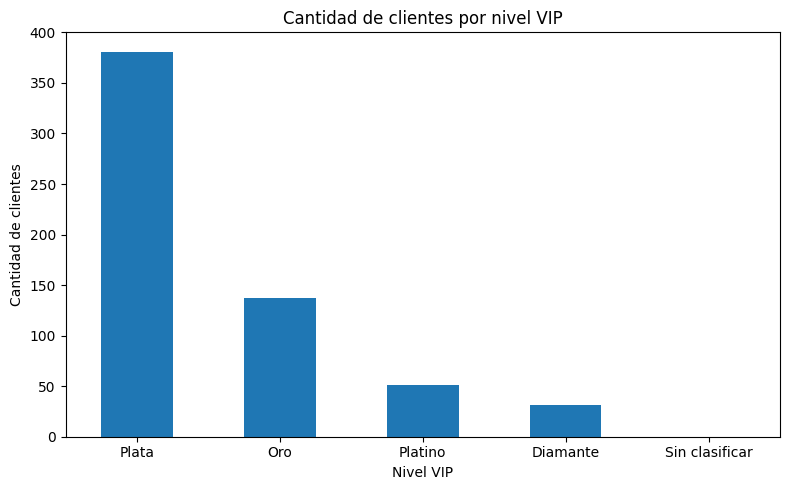

In [74]:
resumen_vip = df_modelo["nivel_vip"].value_counts().sort_index().to_frame("cantidad_clientes")
display(resumen_vip)

plt.figure(figsize=(8, 5))
resumen_vip["cantidad_clientes"].plot(kind="bar")
plt.title("Cantidad de clientes por nivel VIP")
plt.xlabel("Nivel VIP")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [75]:
perfil_vip = df_modelo.groupby("nivel_vip").agg(
    monto_promedio=("monto_gastado", "mean"),
    compras_promedio=("compras_realizadas", "mean"),
    ingreso_promedio=("ingreso_mensual", "mean"),
    deuda_sobre_ingreso_promedio=("deuda_sobre_ingreso", "mean"),
    descuento_promedio=("descuento_recomendado_pct", "mean")
).round(2)

display(perfil_vip)

,monto_promedio,compras_promedio,ingreso_promedio,deuda_sobre_ingreso_promedio,descuento_promedio
nivel_vip,,,,,
Plata,"47,969.94",377.57,"842,711.29",0.27,5.06
Oro,"90,342.30",697.75,"1,925,656.93",0.07,9.97
Platino,"129,342.21","1,019.53","3,374,411.76",0.03,14.78
Diamante,"155,514.37","1,204.35","4,034,516.13",0.03,24.64
Sin clasificar,NaN,NaN,NaN,NaN,NaN


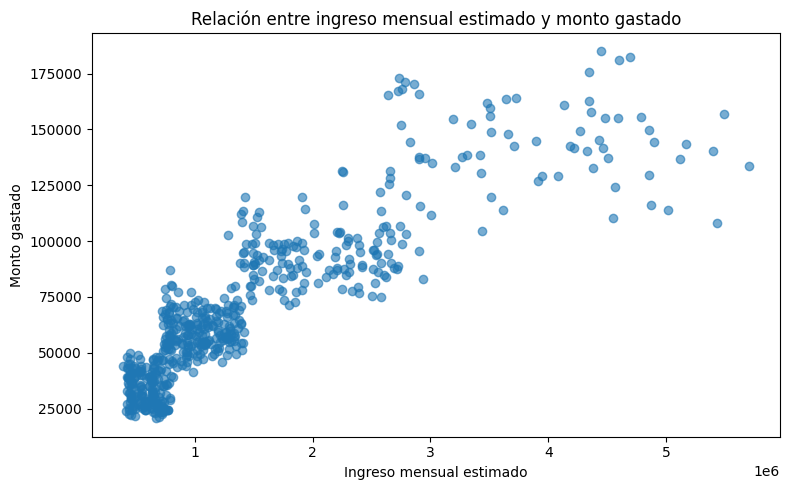

In [76]:
plt.figure(figsize=(8, 5))
plt.scatter(df_modelo["ingreso_mensual"], df_modelo["monto_gastado"], alpha=0.6)
plt.title("Relación entre ingreso mensual estimado y monto gastado")
plt.xlabel("Ingreso mensual estimado")
plt.ylabel("Monto gastado")
plt.tight_layout()
plt.show()

## 22. Codificación final con get_dummies

En la primera prueba se trabajaba con `pd.get_dummies` para convertir variables categóricas en variables numéricas. En esta versión se mantiene esa lógica, pero se ubica después de crear la base de clientes y las variables VIP.

La razón es metodológica: primero construimos las variables de negocio y luego dejamos una tabla final de modelado con variables numéricas, dummies y objetivos supervisados claramente separados.

Las dummies se generan desde las transacciones y luego se resumen por cliente como proporciones. Por ejemplo, una columna dummy con valor `0.70` significa que el 70% de las compras de ese cliente pertenece a esa categoría, canal o medio de pago.


In [77]:
# get_dummies después de crear la base y las variables nuevas
# Aquí se codifican las variables categóricas que vienen del dataset original.
# Se hace en esta etapa para que el flujo quede más claro:
# limpieza -> variables nuevas -> dummies -> resumen final -> modelos.
#
# No se codifica Item directamente porque tiene demasiados productos distintos.
# Para eso se usa Tipo_Producto, que agrupa los productos en familias más interpretables.

columnas_categoricas_dummies = [
    "Tipo_Producto",
    "Category",
    "Payment Method",
    "Location",
    "Discount Applied"
]

df_variables_dummies = pd.get_dummies(
    df_limpio[["Customer ID"] + columnas_categoricas_dummies],
    columns=columnas_categoricas_dummies,
    prefix=["tipo_producto", "categoria", "pago", "canal", "descuento"],
    dtype=int
)

# Función para limpiar nombres de columnas y evitar espacios o caracteres incómodos.
def limpiar_nombre_columna(nombre):
    if nombre == "Customer ID":
        return nombre

    reemplazos = {
        "á": "a", "é": "e", "í": "i", "ó": "o", "ú": "u",
        "Á": "a", "É": "e", "Í": "i", "Ó": "o", "Ú": "u",
        "ñ": "n", "Ñ": "n"
    }

    nombre = str(nombre)
    for original, reemplazo in reemplazos.items():
        nombre = nombre.replace(original, reemplazo)

    return (
        nombre.lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
        .replace(".", "")
        .replace("__", "_")
    )

df_variables_dummies.columns = [
    limpiar_nombre_columna(col)
    for col in df_variables_dummies.columns
]

columnas_dummies_generadas = [
    col for col in df_variables_dummies.columns
    if col != "Customer ID"
]

# Resumen de dummies por cliente
# Como cada columna dummy vale 0 o 1 por transacción, el promedio por cliente
# se interpreta como proporción de comportamiento.
# Ejemplo: canal_online = 0.80 indica que el 80% de sus compras fueron online.

df_dummies_cliente = (
    df_variables_dummies
    .groupby("Customer ID")[columnas_dummies_generadas]
    .mean()
    .reset_index()
)

# Se integran las dummies a la base final usada por los modelos.
df_modelo = df_modelo.merge(df_dummies_cliente, on="Customer ID", how="left")
df_modelo[columnas_dummies_generadas] = df_modelo[columnas_dummies_generadas].fillna(0)

print("Cantidad de dummies generadas:", len(columnas_dummies_generadas))
print("Dimensión final de df_modelo después de incorporar dummies:", df_modelo.shape)

print("\nPrimeras columnas dummy generadas:")
display(pd.DataFrame({"dummy": columnas_dummies_generadas}).head(20))

print("\nResumen de dummies por cliente:")
display(df_dummies_cliente.head())


Cantidad de dummies generadas: 18
Dimensión final de df_modelo después de incorporar dummies: (600, 54)

Primeras columnas dummy generadas:


,dummy
0,tipo_producto_consumo_diario
1,tipo_producto_hogar
2,tipo_producto_tecnologia
3,categoria_beverages
4,categoria_butchers
5,categoria_computers_and_electric_accessories
6,categoria_electric_household_essentials
7,categoria_food
8,categoria_furniture
9,categoria_milk_products



Resumen de dummies por cliente:


,Customer ID,tipo_producto_consumo_diario,tipo_producto_hogar,tipo_producto_tecnologia,categoria_beverages,categoria_butchers,categoria_computers_and_electric_accessories,categoria_electric_household_essentials,categoria_food,categoria_furniture,categoria_milk_products,categoria_patisserie,pago_cash,pago_credit_card,pago_digital_wallet,canal_in_store,canal_online,descuento_false,descuento_true
0,CUST_01,0.61,0.24,0.15,0.13,0.13,0.15,0.11,0.14,0.13,0.10,0.10,0.31,0.33,0.36,0.50,0.50,0.67,0.33
1,CUST_02,0.62,0.30,0.09,0.12,0.13,0.09,0.15,0.12,0.15,0.13,0.12,0.32,0.36,0.32,0.53,0.47,0.67,0.33
2,CUST_03,0.66,0.22,0.11,0.14,0.14,0.11,0.11,0.13,0.12,0.13,0.13,0.35,0.33,0.32,0.49,0.51,0.71,0.29
3,CUST_04,0.59,0.26,0.15,0.14,0.14,0.15,0.14,0.11,0.12,0.12,0.08,0.37,0.31,0.32,0.52,0.48,0.68,0.32
4,CUST_05,0.63,0.26,0.11,0.14,0.13,0.11,0.12,0.11,0.14,0.14,0.12,0.33,0.37,0.30,0.49,0.51,0.61,0.39


## 23. Resumen final del DataFrame de modelado

Antes de entrenar modelos, se revisa una vista limpia de `df_modelo` con las variables principales, las variables simuladas, el sistema VIP y las dummies incorporadas.

Esta sección no cambia el modelo; sirve para demostrar que el dataset final quedó ordenado y que las variables categóricas fueron transformadas correctamente.


In [78]:
# Vista final de df_modelo antes de modelos
# Se arma una vista ordenada para mostrar todas las variables relevantes.
# No todas las columnas de esta vista se usan como predictoras.
# Por ejemplo, nivel_vip y descuento_recomendado_pct son objetivos, no entradas.

columnas_resumen_principales = [
    "Cliente_Modelo_ID",
    "Customer ID",
    "perfil_negocio",
    "monto_gastado",
    "compras_realizadas",
    "ticket_promedio",
    "ingreso_mensual",
    "deuda_actual",
    "deuda_sobre_ingreso",
    "edad",
    "antiguedad_cliente_meses",
    "meses_vip",
    "recencia_dias",
    "score_vip",
    "nivel_vip",
    "descuento_recomendado_pct"
]

columnas_resumen_final = columnas_resumen_principales + columnas_dummies_generadas
columnas_resumen_final = [col for col in columnas_resumen_final if col in df_modelo.columns]

df_modelo_resumen = df_modelo[columnas_resumen_final].copy()

print("Dimensión de df_modelo:", df_modelo.shape)
print("Cantidad total de variables en la vista resumen:", df_modelo_resumen.shape[1])
print("Cantidad de variables dummy visibles:", len(columnas_dummies_generadas))

resumen_columnas = pd.DataFrame({
    "columna": df_modelo_resumen.columns,
    "tipo_dato": [str(df_modelo_resumen[col].dtype) for col in df_modelo_resumen.columns],
    "es_dummy": [col in columnas_dummies_generadas for col in df_modelo_resumen.columns]
})

print("\nResumen de columnas finales:")
display(resumen_columnas)

print("\nVista del DataFrame final con variables principales y dummies:")
with pd.option_context("display.max_columns", None, "display.width", 200):
    display(df_modelo_resumen.head())


Dimensión de df_modelo: (600, 54)
Cantidad total de variables en la vista resumen: 34
Cantidad de variables dummy visibles: 18

Resumen de columnas finales:


,columna,tipo_dato,es_dummy
0,Cliente_Modelo_ID,object,False
1,Customer ID,object,False
2,perfil_negocio,object,False
3,monto_gastado,float64,False
4,compras_realizadas,int64,False
5,ticket_promedio,float64,False
6,ingreso_mensual,int64,False
7,deuda_actual,int64,False
8,deuda_sobre_ingreso,float64,False
9,edad,int64,False



Vista del DataFrame final con variables principales y dummies:


,Cliente_Modelo_ID,Customer ID,perfil_negocio,monto_gastado,compras_realizadas,ticket_promedio,ingreso_mensual,deuda_actual,deuda_sobre_ingreso,edad,antiguedad_cliente_meses,meses_vip,recencia_dias,score_vip,nivel_vip,descuento_recomendado_pct,tipo_producto_consumo_diario,tipo_producto_hogar,tipo_producto_tecnologia,categoria_beverages,categoria_butchers,categoria_computers_and_electric_accessories,categoria_electric_household_essentials,categoria_food,categoria_furniture,categoria_milk_products,categoria_patisserie,pago_cash,pago_credit_card,pago_digital_wallet,canal_in_store,canal_online,descuento_false,descuento_true
0,CLI_SIM_0001,CUST_03,Alto valor,"86,238.40",619,155.44,2556000,511569,0.20,46,45,21,24,0.42,Oro,9.90,0.66,0.22,0.11,0.14,0.14,0.11,0.11,0.13,0.12,0.13,0.13,0.35,0.33,0.32,0.49,0.51,0.71,0.29
1,CLI_SIM_0002,CUST_20,Ocasional,"31,971.30",299,77.55,706000,179577,0.25,28,5,0,68,0.23,Plata,5.20,0.62,0.25,0.13,0.13,0.12,0.13,0.10,0.13,0.15,0.12,0.12,0.35,0.34,0.32,0.50,0.50,0.66,0.34
2,CLI_SIM_0003,CUST_17,Regular,"53,988.15",397,107.33,1136000,182188,0.16,38,11,5,71,0.28,Plata,4.50,0.64,0.24,0.12,0.14,0.16,0.12,0.12,0.11,0.12,0.12,0.10,0.32,0.33,0.34,0.49,0.51,0.64,0.36
3,CLI_SIM_0004,CUST_11,Regular,"51,179.62",463,135.64,1069000,435387,0.41,37,30,9,76,0.35,Plata,5.60,0.63,0.24,0.13,0.12,0.12,0.13,0.13,0.12,0.11,0.15,0.12,0.35,0.34,0.31,0.48,0.52,0.67,0.33
4,CLI_SIM_0005,CUST_11,Alto valor,"94,840.56",951,200.19,1495000,137525,0.09,42,50,32,39,0.54,Oro,8.90,0.63,0.24,0.13,0.12,0.12,0.13,0.13,0.12,0.11,0.15,0.12,0.35,0.34,0.31,0.48,0.52,0.67,0.33


## 24. Selección de variables para clustering

Después de incorporar las variables numéricas y las dummies, se define qué columnas entran al modelo K-Means.

No se usa `nivel_vip`, `score_vip` ni `descuento_recomendado_pct` como variables predictoras, porque son resultados construidos por el sistema. Usarlas como entrada generaría fuga de información.


In [79]:
variables_base_modelo = [
    "monto_gastado",
    "compras_realizadas",
    "ticket_promedio",
    "ingreso_mensual",
    "deuda_actual",
    "deuda_sobre_ingreso",
    "edad",
    "antiguedad_cliente_meses",
    "meses_vip",
    "recencia_dias",
    "porcentaje_online",
    "porcentaje_descuento",
    "productos_distintos",
    "categorias_distintas",
    "tipos_producto_distintos",
    "metodos_pago_distintos"
]

# Se agregan las dummies resumidas por cliente.
# Para evitar redundancia, se excluyen las dummies de descuento porque ya existe porcentaje_descuento.
# Las dummies de tipo_producto y categoria quedan disponibles como comportamiento de compra.
variables_dummies_modelo = [
    col for col in columnas_dummies_generadas
    if not col.startswith("descuento_")
]

variables_modelo = variables_base_modelo + variables_dummies_modelo

X_cluster = df_modelo[variables_modelo].copy()

print("Cantidad de variables usadas para clustering:", len(variables_modelo))
print("Variables dummy incluidas:", variables_dummies_modelo)
X_cluster.head()

Cantidad de variables usadas para clustering: 32
Variables dummy incluidas: ['tipo_producto_consumo_diario', 'tipo_producto_hogar', 'tipo_producto_tecnologia', 'categoria_beverages', 'categoria_butchers', 'categoria_computers_and_electric_accessories', 'categoria_electric_household_essentials', 'categoria_food', 'categoria_furniture', 'categoria_milk_products', 'categoria_patisserie', 'pago_cash', 'pago_credit_card', 'pago_digital_wallet', 'canal_in_store', 'canal_online']


,monto_gastado,compras_realizadas,ticket_promedio,ingreso_mensual,deuda_actual,deuda_sobre_ingreso,edad,antiguedad_cliente_meses,meses_vip,recencia_dias,porcentaje_online,porcentaje_descuento,productos_distintos,categorias_distintas,tipos_producto_distintos,metodos_pago_distintos,tipo_producto_consumo_diario,tipo_producto_hogar,tipo_producto_tecnologia,categoria_beverages,categoria_butchers,categoria_computers_and_electric_accessories,categoria_electric_household_essentials,categoria_food,categoria_furniture,categoria_milk_products,categoria_patisserie,pago_cash,pago_credit_card,pago_digital_wallet,canal_in_store,canal_online
0,"86,238.40",619,155.44,2556000,511569,0.20,46,45,21,24,0.50,0.27,162,8,3,3,0.66,0.22,0.11,0.14,0.14,0.11,0.11,0.13,0.12,0.13,0.13,0.35,0.33,0.32,0.49,0.51
1,"31,971.30",299,77.55,706000,179577,0.25,28,5,0,68,0.43,0.33,162,8,3,3,0.62,0.25,0.13,0.13,0.12,0.13,0.10,0.13,0.15,0.12,0.12,0.35,0.34,0.32,0.50,0.50
2,"53,988.15",397,107.33,1136000,182188,0.16,38,11,5,71,0.48,0.39,160,8,3,3,0.64,0.24,0.12,0.14,0.16,0.12,0.12,0.11,0.12,0.12,0.10,0.32,0.33,0.34,0.49,0.51
3,"51,179.62",463,135.64,1069000,435387,0.41,37,30,9,76,0.46,0.38,162,8,3,3,0.63,0.24,0.13,0.12,0.12,0.13,0.13,0.12,0.11,0.15,0.12,0.35,0.34,0.31,0.48,0.52
4,"94,840.56",951,200.19,1495000,137525,0.09,42,50,32,39,0.53,0.28,162,8,3,3,0.63,0.24,0.13,0.12,0.12,0.13,0.13,0.12,0.11,0.15,0.12,0.35,0.34,0.31,0.48,0.52


## 25. Escalar variables

Antes de aplicar K-Means y PCA se escalan las variables con `StandardScaler`.

Esto es necesario porque las variables tienen escalas muy distintas. Por ejemplo, `ingreso_mensual` puede estar en cientos de miles o millones, mientras que `deuda_sobre_ingreso` está entre 0 y 1. Si no se escala, las variables con números más grandes pueden dominar el cálculo de distancias.

Escalar no cambia el orden ni el sentido de los datos. Solo deja las variables en una escala comparable.


In [80]:
# Escalamiento de variables para modelos sensibles a distancia
# K-Means calcula cercanía entre clientes. PCA también depende de la escala.
# Por eso se usa StandardScaler antes de entrenar esos modelos.

escalador_cluster = StandardScaler()
X_cluster_escalado = escalador_cluster.fit_transform(df_modelo[variables_modelo])

print("Matriz escalada para clustering:")
print("Filas:", X_cluster_escalado.shape[0])
print("Columnas:", X_cluster_escalado.shape[1])

Matriz escalada para clustering:
Filas: 600
Columnas: 32


## 26. Evaluación de K-Means con varios valores de K

Antes de definir el modelo final, se prueban distintos valores de `K` para revisar qué agrupamiento separa mejor a los clientes.

Se comparan estos valores:

- K = 2
- K = 3
- K = 4
- K = 5
- K = 6

Se parte desde **K=2** porque `Silhouette Score` necesita al menos dos clusters. K=1 no permite medir separación entre grupos.

La decisión final se apoya principalmente en **Silhouette Score**, porque esta métrica evalúa qué tan bien separado está cada cliente respecto a su propio cluster y los demás clusters.

También se revisa **Inertia** mediante el método del codo, pero no se usa sola porque tiende a bajar cuando aumenta K.


In [81]:
# Evaluación de varios valores de K
# En clustering no existe una etiqueta real correcta como en clasificación.
# Por eso no usamos accuracy ni matriz de confusión para elegir K.
# Aquí se entrenan varios modelos K-Means, uno por cada valor de K.
# El objetivo es comparar sus métricas antes de elegir el modelo final.
# Métricas usadas:
# - Inertia: mide compactación interna. Menor inertia significa grupos más compactos.
#   Cuidado: casi siempre baja al aumentar K, por eso no se usa sola.
# - Silhouette: mide separación entre clusters. Mayor valor significa mejor separación.
#
# En esta solución se usa Silhouette como criterio principal.

resultados_kmeans = []
valores_k = range(2, 7)

for k in valores_k:
    # Se crea un modelo K-Means con k clusters.
    modelo_kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    # fit_predict entrena el modelo y asigna cada cliente a un cluster.
    clusters = modelo_kmeans.fit_predict(X_cluster_escalado)

    # Inertia: qué tan cerca quedan los clientes de su centroide.
    inertia = modelo_kmeans.inertia_

    # Silhouette: qué tan bien separado está cada cliente de otros grupos.
    silhouette = silhouette_score(X_cluster_escalado, clusters)

    resultados_kmeans.append({
        "k": k,
        "inertia": inertia,
        "silhouette": silhouette
    })

# Tabla resumen para justificar la elección de K.
df_resultados_kmeans = pd.DataFrame(resultados_kmeans)

# Se agrega una lectura simple para apoyar la explicación oral.
df_resultados_kmeans["lectura"] = np.where(
    df_resultados_kmeans["silhouette"] == df_resultados_kmeans["silhouette"].max(),
    "Mejor separación según Silhouette",
    "Alternativa evaluada"
)

display(df_resultados_kmeans.round(4))

# K recomendado por Silhouette.
mejor_k_silhouette = int(
    df_resultados_kmeans.loc[
        df_resultados_kmeans["silhouette"].idxmax(),
        "k"
    ]
)

print(f"Mejor K según Silhouette: {mejor_k_silhouette}")
print("Conclusión técnica: se selecciona K=2 porque obtiene la mejor separación promedio.")
print("Conclusión de negocio: K=2 permite separar clientes de alto valor y clientes de menor valor o por desarrollar.")

,k,inertia,silhouette,lectura
0,2,"14,267.45",0.17,Mejor separación según Silhouette
1,3,"13,009.53",0.16,Alternativa evaluada
2,4,"12,148.06",0.17,Alternativa evaluada
3,5,"11,465.14",0.12,Alternativa evaluada
4,6,"10,663.76",0.14,Alternativa evaluada


Mejor K según Silhouette: 2
Conclusión técnica: se selecciona K=2 porque obtiene la mejor separación promedio.
Conclusión de negocio: K=2 permite separar clientes de alto valor y clientes de menor valor o por desarrollar.


## 27. Gráficos para justificar K

Se usan dos gráficos principales:

1. **Método del codo con Inertia:** permite observar si al aumentar K la mejora deja de ser relevante.
2. **Silhouette Score:** permite comparar separación entre clusters.

Para esta solución, Silhouette es el criterio principal. Si K=2 tiene el valor más alto, se interpreta que los datos se separan mejor en dos grupos naturales.


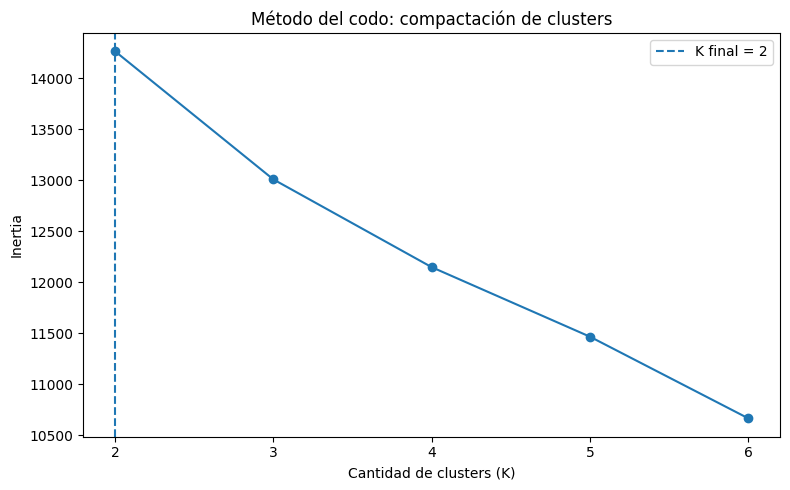

In [82]:
plt.figure(figsize=(8, 5))
plt.plot(df_resultados_kmeans["k"], df_resultados_kmeans["inertia"], marker="o")
plt.axvline(x=2, linestyle="--", label="K final = 2")
plt.title("Método del codo: compactación de clusters")
plt.xlabel("Cantidad de clusters (K)")
plt.ylabel("Inertia")
plt.xticks(df_resultados_kmeans["k"])
plt.legend()
plt.tight_layout()
plt.show()

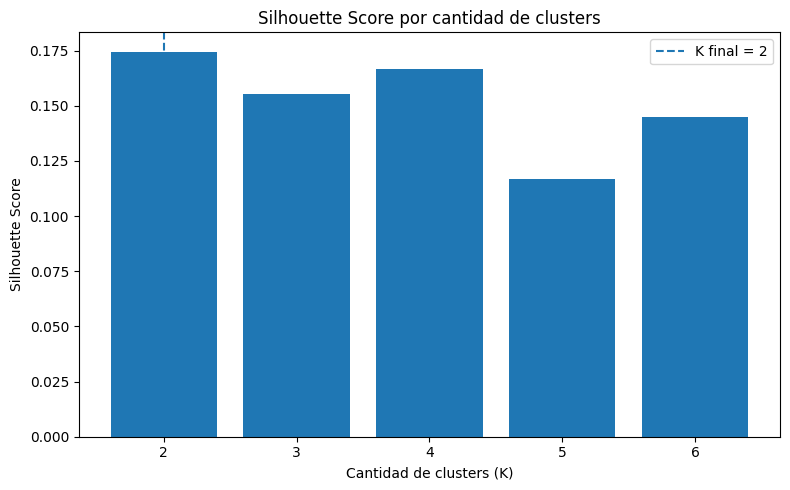

In [83]:
plt.figure(figsize=(8, 5))
plt.bar(df_resultados_kmeans["k"], df_resultados_kmeans["silhouette"])
plt.axvline(x=2, linestyle="--", label="K final = 2")
plt.title("Silhouette Score por cantidad de clusters")
plt.xlabel("Cantidad de clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(df_resultados_kmeans["k"])
plt.legend()
plt.tight_layout()
plt.show()

## 28. Aplicación final de K-Means con K=2

Después de comparar varios valores de K, el modelo final se aplica con **K=2**.

La elección se justifica así:

- `Silhouette Score` indica que K=2 entrega la separación promedio más clara.
- K=2 evita forzar cuatro grupos cuando los datos se separan naturalmente mejor en dos perfiles.
- La interpretación es simple y defendible: **clientes de alto valor** y **clientes de menor valor o por desarrollar**.
- Los cuatro niveles VIP —Plata, Oro, Platino y Diamante— se mantienen para la parte supervisada: árbol de decisión y descuento recomendado.


In [84]:
# K-Means final con K=2
# En la etapa anterior se entrenaron modelos de prueba con K=2,3,4,5,6.
# Según Silhouette, K=2 entrega la separación más clara.
#
# Este K-Means final NO reemplaza los niveles VIP.
# Su objetivo es separar a los clientes en dos grandes grupos naturales:
# - clientes de alto valor o prioritarios
# - clientes de menor valor o por desarrollar

K_FINAL = 2

kmeans_final = KMeans(
    n_clusters=K_FINAL,
    random_state=RANDOM_STATE,
    n_init=10
)

df_modelo["cluster_kmeans"] = kmeans_final.fit_predict(X_cluster_escalado)

print("Cantidad de clientes por cluster:")
display(df_modelo["cluster_kmeans"].value_counts().sort_index().to_frame("clientes"))

silhouette_final = silhouette_score(X_cluster_escalado, df_modelo["cluster_kmeans"])
print("Silhouette del modelo final K=2:")
print(round(silhouette_final, 4))

print("\nInterpretación:")
print("K=2 se usa porque entrega una separación clara entre dos perfiles generales de clientes.")
print("Los niveles Plata, Oro, Platino y Diamante se mantienen para la clasificación supervisada.")

Cantidad de clientes por cluster:


,clientes
cluster_kmeans,
0,389
1,211


Silhouette del modelo final K=2:
0.1746

Interpretación:
K=2 se usa porque entrega una separación clara entre dos perfiles generales de clientes.
Los niveles Plata, Oro, Platino y Diamante se mantienen para la clasificación supervisada.


## 29. Perfil de clusters

El número del cluster por sí solo no significa nada. `Cluster 0` y `Cluster 1` son nombres técnicos generados por el algoritmo.

Para darles sentido, se revisan los promedios de cada grupo. Esta tabla responde preguntas como:

- ¿Qué cluster gasta más?
- ¿Qué cluster tiene mayor frecuencia de compra?
- ¿Qué cluster tiene mayor ingreso mensual estimado?
- ¿Qué cluster tiene menor o mayor relación deuda/ingreso?
- ¿Qué cluster parece tener mayor valor comercial?

Esta parte es clave para la defensa, porque transforma el resultado técnico en interpretación de negocio.


In [85]:
# Promedio de cada variable por cluster.
# Esta tabla es la base para interpretar los clusters.
perfil_clusters = df_modelo.groupby("cluster_kmeans")[variables_modelo].mean().round(2)
display(perfil_clusters)

,monto_gastado,compras_realizadas,ticket_promedio,ingreso_mensual,deuda_actual,deuda_sobre_ingreso,edad,antiguedad_cliente_meses,meses_vip,recencia_dias,porcentaje_online,porcentaje_descuento,productos_distintos,categorias_distintas,tipos_producto_distintos,metodos_pago_distintos,tipo_producto_consumo_diario,tipo_producto_hogar,tipo_producto_tecnologia,categoria_beverages,categoria_butchers,categoria_computers_and_electric_accessories,categoria_electric_household_essentials,categoria_food,categoria_furniture,categoria_milk_products,categoria_patisserie,pago_cash,pago_credit_card,pago_digital_wallet,canal_in_store,canal_online
cluster_kmeans,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,"48,217.75",378.23,96.65,"840,655.53","207,253.79",0.26,29.13,16.58,4.44,81.43,0.51,0.34,163.24,8.00,3.00,3.00,0.62,0.25,0.12,0.13,0.13,0.12,0.13,0.13,0.13,0.13,0.12,0.34,0.33,0.33,0.49,0.51
1,"110,493.54",860.88,219.81,"2,630,511.85","113,643.40",0.05,45.35,44.49,24.43,22.27,0.50,0.34,162.42,8.00,3.00,3.00,0.63,0.25,0.12,0.12,0.12,0.12,0.13,0.13,0.13,0.13,0.12,0.34,0.33,0.33,0.49,0.51


In [86]:
# Perfil estandarizado de clusters
# Algunas variables tienen escalas muy distintas. Por eso se estandariza el perfil
# solo para comparar mejor el comportamiento relativo de los clusters.
#
# Valores positivos: el cluster está sobre el promedio general.
# Valores negativos: el cluster está bajo el promedio general.

perfil_clusters_escalado = pd.DataFrame(
    StandardScaler().fit_transform(perfil_clusters),
    index=perfil_clusters.index,
    columns=perfil_clusters.columns
)

variables_perfil_grafico = [
    "monto_gastado",
    "compras_realizadas",
    "ingreso_mensual",
    "deuda_sobre_ingreso",
    "antiguedad_cliente_meses",
    "recencia_dias"
]

display(perfil_clusters_escalado[variables_perfil_grafico].round(2))

,monto_gastado,compras_realizadas,ingreso_mensual,deuda_sobre_ingreso,antiguedad_cliente_meses,recencia_dias
cluster_kmeans,,,,,,
0,-1.00,-1.00,-1.00,1.00,-1.00,1.00
1,1.00,1.00,1.00,-1.00,1.00,-1.00


## 30. Nombres interpretables para los clusters

Python solo entrega números de cluster. Para presentar el resultado de forma entendible, se asignan nombres de negocio usando los promedios de cada grupo.

Los nombres no salen automáticamente del algoritmo. Se construyen mirando el perfil de cada cluster.

En este notebook se nombran dos segmentos:

- **Clientes de alto valor o prioritarios:** grupo con mayor gasto, mayor frecuencia, mejor ticket promedio, mayor ingreso o menor relación deuda/ingreso.
- **Clientes de menor valor o por desarrollar:** grupo con menor valor comercial relativo o que necesita acciones de crecimiento, retención o reactivación.

Esto permite explicar K-Means como una segmentación general. Los niveles Plata, Oro, Platino y Diamante quedan para el modelo supervisado de clasificación VIP.


In [87]:
# Asignación de nombres de negocio a clusters para K=2
# K-Means entrega números de cluster, pero esos números no tienen
# significado comercial por sí solos.
#
# Para nombrarlos, calculamos un indicador simple de valor:
# - suma positivamente gasto, compras, ticket, ingreso, antigüedad y meses VIP.
# - resta la relación deuda/ingreso, porque mayor deuda relativa implica mayor riesgo.
#
# El cluster con mayor indicador se interpreta como alto valor.
# El otro cluster queda como menor valor o por desarrollar.

perfil_para_nombres = perfil_clusters.copy()

perfil_para_nombres["indicador_valor"] = (
    perfil_para_nombres["monto_gastado"].rank(ascending=True) +
    perfil_para_nombres["compras_realizadas"].rank(ascending=True) +
    perfil_para_nombres["ticket_promedio"].rank(ascending=True) +
    perfil_para_nombres["ingreso_mensual"].rank(ascending=True) +
    perfil_para_nombres["antiguedad_cliente_meses"].rank(ascending=True) +
    perfil_para_nombres["meses_vip"].rank(ascending=True) -
    perfil_para_nombres["deuda_sobre_ingreso"].rank(ascending=True)
)

cluster_alto_valor = perfil_para_nombres["indicador_valor"].idxmax()
cluster_menor_valor = perfil_para_nombres["indicador_valor"].idxmin()

cluster_labels = {
    cluster_alto_valor: "Clientes de alto valor o prioritarios",
    cluster_menor_valor: "Clientes de menor valor o por desarrollar"
}

# Se aplica el diccionario de nombres al dataset.
df_modelo["nombre_cluster"] = df_modelo["cluster_kmeans"].map(cluster_labels)

# Tabla para explicar qué nombre recibió cada cluster.
tabla_nombres_clusters = (
    pd.DataFrame({
        "cluster_kmeans": list(cluster_labels.keys()),
        "nombre_de_negocio": list(cluster_labels.values())
    })
    .sort_values("cluster_kmeans")
    .reset_index(drop=True)
)

display(tabla_nombres_clusters)

display(
    perfil_para_nombres[[
        "monto_gastado",
        "compras_realizadas",
        "ticket_promedio",
        "ingreso_mensual",
        "deuda_sobre_ingreso",
        "indicador_valor"
    ]].round(2)
)

,cluster_kmeans,nombre_de_negocio
0,0,Clientes de menor valor o por desarrollar
1,1,Clientes de alto valor o prioritarios


,monto_gastado,compras_realizadas,ticket_promedio,ingreso_mensual,deuda_sobre_ingreso,indicador_valor
cluster_kmeans,,,,,,
0,"48,217.75",378.23,96.65,"840,655.53",0.26,4.00
1,"110,493.54",860.88,219.81,"2,630,511.85",0.05,11.00


,clientes
nombre_cluster,
Clientes de menor valor o por desarrollar,389
Clientes de alto valor o prioritarios,211


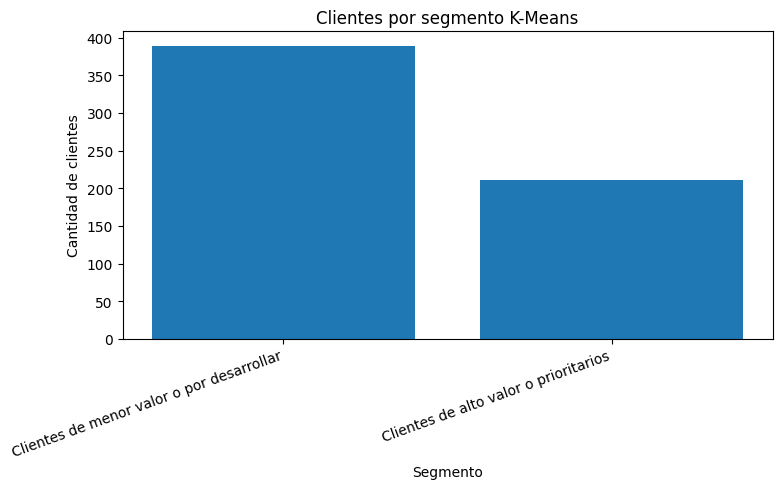

In [88]:
# Gráfico de cantidad de clientes por segmento K-Means
# Este gráfico sirve para presentar el resultado final de clustering.
# Ya no mostramos solo cluster 0 y cluster 1; usamos nombres de negocio.

conteo_segmentos = df_modelo["nombre_cluster"].value_counts()

display(conteo_segmentos.to_frame("clientes"))

plt.figure(figsize=(8, 5))
plt.bar(conteo_segmentos.index, conteo_segmentos.values)
plt.title("Clientes por segmento K-Means")
plt.xlabel("Segmento")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

<Figure size 1100x500 with 0 Axes>

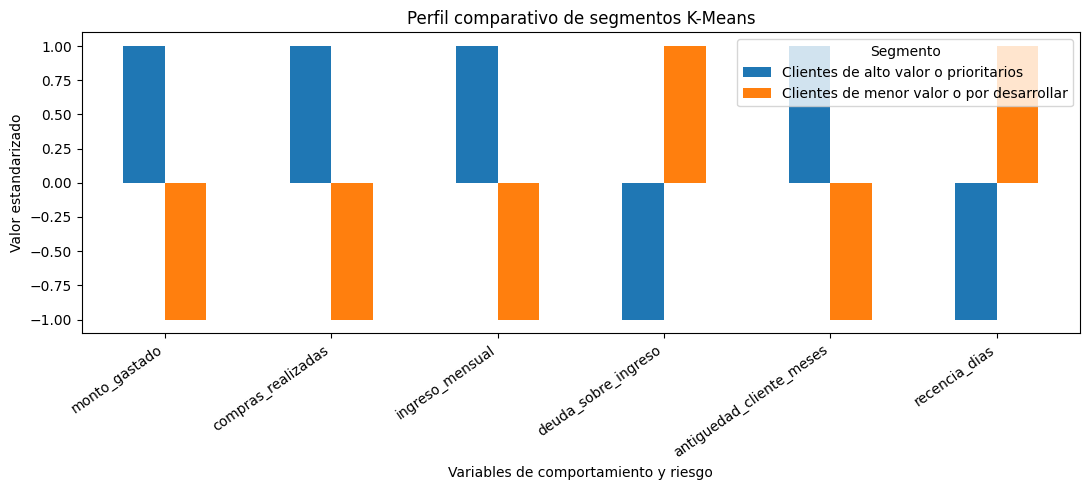

,monto_gastado,compras_realizadas,ingreso_mensual,deuda_sobre_ingreso,antiguedad_cliente_meses,recencia_dias
nombre_cluster,,,,,,
Clientes de alto valor o prioritarios,"110,493.54",860.88,"2,630,511.85",0.05,44.49,22.27
Clientes de menor valor o por desarrollar,"48,217.75",378.23,"840,655.53",0.26,16.58,81.43


In [89]:
# Perfil comparativo de los segmentos con nombres de negocio
# y el otro como menor valor o por desarrollar.

perfil_segmentos = df_modelo.groupby("nombre_cluster")[variables_perfil_grafico].mean()

perfil_segmentos_escalado = pd.DataFrame(
    StandardScaler().fit_transform(perfil_segmentos),
    index=perfil_segmentos.index,
    columns=perfil_segmentos.columns
)

plt.figure(figsize=(11, 5))
perfil_segmentos_escalado.T.plot(kind="bar", figsize=(11, 5))
plt.title("Perfil comparativo de segmentos K-Means")
plt.xlabel("Variables de comportamiento y riesgo")
plt.ylabel("Valor estandarizado")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Segmento")
plt.tight_layout()
plt.show()

display(perfil_segmentos.round(2))

## 31. PCA para visualizar clusters

PCA se usa para visualizar los clusters en dos dimensiones.

Hay que evitar una confusión típica: **PCA no crea los clusters**. Los clusters ya fueron creados por K-Means. PCA solo resume muchas variables en dos componentes principales para poder dibujarlas en un gráfico 2D.

En esta sección se comparan dos vistas:

1. **Vista sin PCA:** se grafican solo dos variables originales, como ingreso y monto gastado.
2. **Vista con PCA:** se grafican PC1 y PC2, que resumen varias variables al mismo tiempo.

Esto permite explicar mejor si los grupos se ven separados o mezclados.


In [90]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
componentes_pca = pca.fit_transform(X_cluster_escalado)

df_modelo["PC1"] = componentes_pca[:, 0]
df_modelo["PC2"] = componentes_pca[:, 1]

varianza_pca = pca.explained_variance_ratio_
print("Varianza explicada por PC1:", round(varianza_pca[0] * 100, 2), "%")
print("Varianza explicada por PC2:", round(varianza_pca[1] * 100, 2), "%")
print("Varianza total explicada:", round(varianza_pca.sum() * 100, 2), "%")

Varianza explicada por PC1: 24.76 %
Varianza explicada por PC2: 14.93 %
Varianza total explicada: 39.69 %


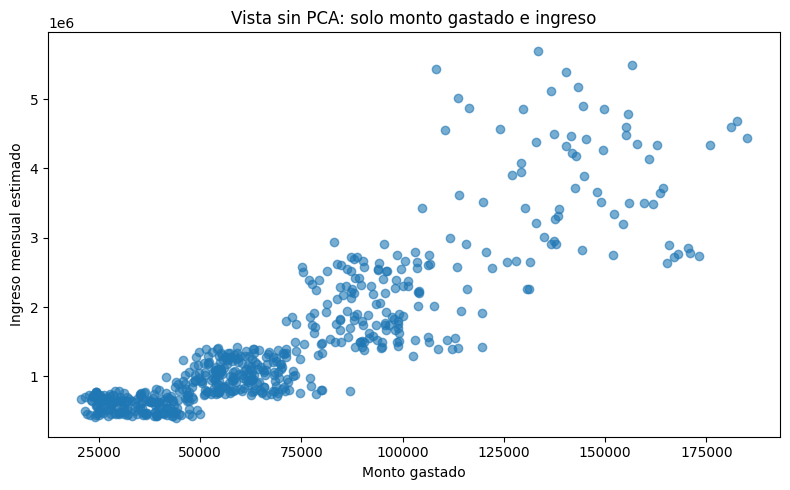

In [91]:
plt.figure(figsize=(8, 5))
plt.scatter(df_modelo["monto_gastado"], df_modelo["ingreso_mensual"], alpha=0.6)
plt.title("Vista sin PCA: solo monto gastado e ingreso")
plt.xlabel("Monto gastado")
plt.ylabel("Ingreso mensual estimado")
plt.tight_layout()
plt.show()

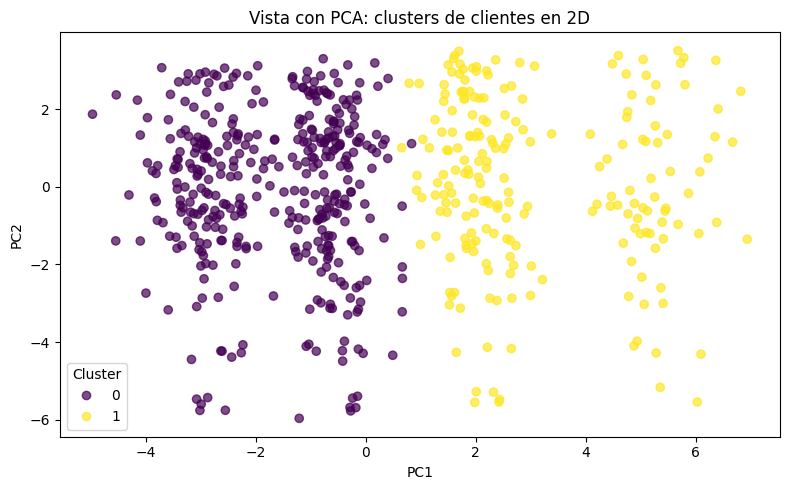

In [92]:
plt.figure(figsize=(8, 5))
scatter = plt.scatter(
    df_modelo["PC1"],
    df_modelo["PC2"],
    c=df_modelo["cluster_kmeans"],
    alpha=0.7
)
plt.title("Vista con PCA: clusters de clientes en 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.show()

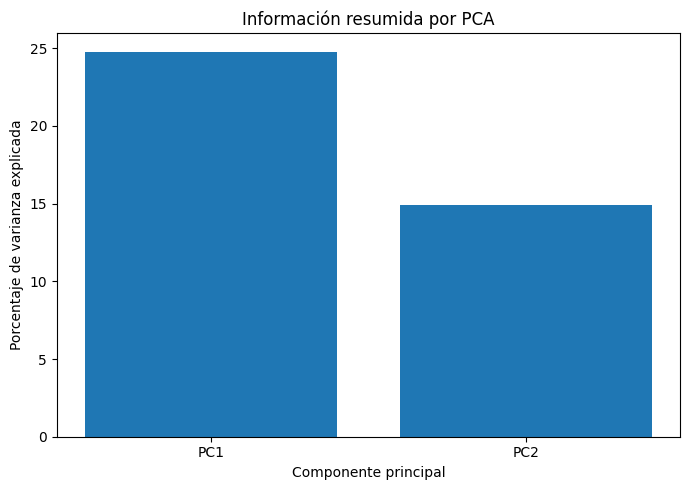

In [93]:
plt.figure(figsize=(7, 5))
plt.bar(["PC1", "PC2"], varianza_pca * 100)
plt.title("Información resumida por PCA")
plt.xlabel("Componente principal")
plt.ylabel("Porcentaje de varianza explicada")
plt.tight_layout()
plt.show()

## 32. Comparación entre segmentos K-Means y nivel VIP

Esta sección compara los dos segmentos creados por K-Means con los niveles VIP definidos por la regla de negocio.

No debe interpretarse como equivalencia exacta. K-Means no conoce las etiquetas Plata, Oro, Platino o Diamante. Solo agrupa por similitud de variables.

La lectura esperada es aproximada:

- El segmento de **alto valor** debería concentrar mayor proporción de clientes Oro, Platino y Diamante.
- El segmento de **menor valor o por desarrollar** debería concentrar mayor proporción de clientes Plata y parte de Oro.

Esta comparación sirve para conectar el modelo no supervisado con la lógica comercial del sistema VIP.


nivel_vip,Plata,Oro,Platino,Diamante
nombre_cluster,,,,
Clientes de alto valor o prioritarios,0.03,0.58,0.24,0.15
Clientes de menor valor o por desarrollar,0.96,0.04,0.00,0.00


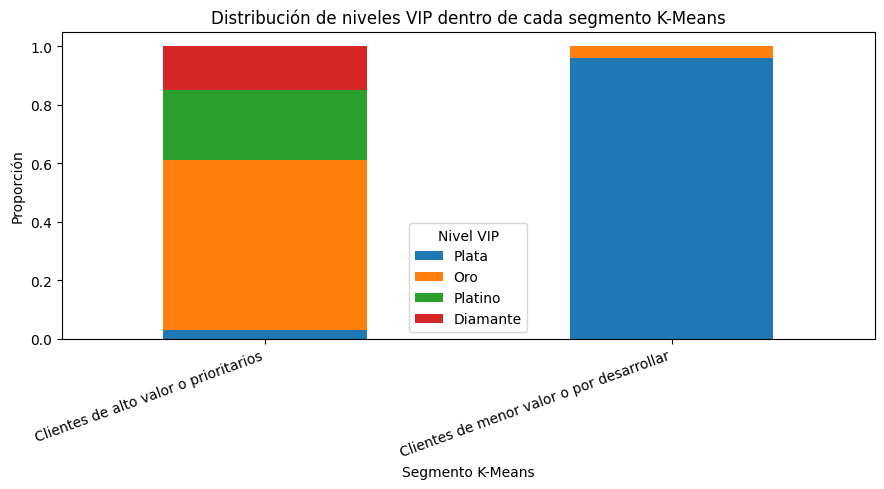

In [94]:
# Cruce entre segmento K-Means y nivel VIP
# Esta tabla muestra qué proporción de niveles VIP aparece dentro de cada segmento.
# Como K-Means no usa la etiqueta VIP, esta comparación es solo interpretativa.

tabla_cluster_vip = pd.crosstab(
    df_modelo["nombre_cluster"],
    df_modelo["nivel_vip"],
    normalize="index"
).round(2)

display(tabla_cluster_vip)

# Gráfico apilado para explicar la relación entre clustering y niveles VIP.
tabla_cluster_vip.plot(kind="bar", stacked=True, figsize=(9, 5))
plt.title("Distribución de niveles VIP dentro de cada segmento K-Means")
plt.xlabel("Segmento K-Means")
plt.ylabel("Proporción")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Nivel VIP")
plt.tight_layout()
plt.show()

## 33. Preparación para modelos supervisados

Después del clustering se pasa a modelos supervisados.

Aquí sí existe una variable objetivo:

- Para regresión: `descuento_recomendado_pct`.
- Para clasificación: `nivel_vip`.

Se debe evitar fuga de información. Por eso no se usan como variables predictoras columnas que revelen directamente la respuesta, como `score_vip`, `nivel_vip`, `descuento_recomendado_pct` o `cluster_kmeans`.

El objetivo es que el modelo aprenda desde variables de comportamiento y perfil del cliente, no desde la respuesta ya calculada.


In [95]:
features_supervisadas = variables_modelo.copy()

# No se usan como predictores las columnas creadas directamente desde la respuesta.
# Esto evita fuga de información: el modelo no debe recibir la respuesta ya calculada.
columnas_no_predictoras = [
    "score_vip",
    "nivel_vip",
    "descuento_recomendado_pct",
    "cluster_kmeans",
    "nombre_cluster"
]

X = df_modelo[features_supervisadas]

print("Cantidad de variables predictoras supervisadas:", len(features_supervisadas))
display(X.head())

Cantidad de variables predictoras supervisadas: 32


,monto_gastado,compras_realizadas,ticket_promedio,ingreso_mensual,deuda_actual,deuda_sobre_ingreso,edad,antiguedad_cliente_meses,meses_vip,recencia_dias,porcentaje_online,porcentaje_descuento,productos_distintos,categorias_distintas,tipos_producto_distintos,metodos_pago_distintos,tipo_producto_consumo_diario,tipo_producto_hogar,tipo_producto_tecnologia,categoria_beverages,categoria_butchers,categoria_computers_and_electric_accessories,categoria_electric_household_essentials,categoria_food,categoria_furniture,categoria_milk_products,categoria_patisserie,pago_cash,pago_credit_card,pago_digital_wallet,canal_in_store,canal_online
0,"86,238.40",619,155.44,2556000,511569,0.20,46,45,21,24,0.50,0.27,162,8,3,3,0.66,0.22,0.11,0.14,0.14,0.11,0.11,0.13,0.12,0.13,0.13,0.35,0.33,0.32,0.49,0.51
1,"31,971.30",299,77.55,706000,179577,0.25,28,5,0,68,0.43,0.33,162,8,3,3,0.62,0.25,0.13,0.13,0.12,0.13,0.10,0.13,0.15,0.12,0.12,0.35,0.34,0.32,0.50,0.50
2,"53,988.15",397,107.33,1136000,182188,0.16,38,11,5,71,0.48,0.39,160,8,3,3,0.64,0.24,0.12,0.14,0.16,0.12,0.12,0.11,0.12,0.12,0.10,0.32,0.33,0.34,0.49,0.51
3,"51,179.62",463,135.64,1069000,435387,0.41,37,30,9,76,0.46,0.38,162,8,3,3,0.63,0.24,0.13,0.12,0.12,0.13,0.13,0.12,0.11,0.15,0.12,0.35,0.34,0.31,0.48,0.52
4,"94,840.56",951,200.19,1495000,137525,0.09,42,50,32,39,0.53,0.28,162,8,3,3,0.63,0.24,0.13,0.12,0.12,0.13,0.13,0.12,0.11,0.15,0.12,0.35,0.34,0.31,0.48,0.52


## 34. Modelo de regresión: predecir descuento recomendado

La regresión se utiliza para estimar un valor numérico: el porcentaje de descuento recomendado para cada cliente. Como ahora el descuento incluye una variación controlada, el problema es más realista: el modelo no solo memoriza un descuento fijo por nivel VIP, sino que debe aproximar un beneficio comercial a partir de las variables del cliente.


In [96]:
y_regresion = df_modelo["descuento_recomendado_pct"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_regresion,
    test_size=0.20,
    random_state=RANDOM_STATE
)

modelos_regresion = {
    "Modelo lineal básico": LinearRegression(),
    "Árbol de descuentos": DecisionTreeRegressor(max_depth=4, random_state=RANDOM_STATE),
    "Bosque de descuentos": RandomForestRegressor(n_estimators=120, max_depth=6, random_state=RANDOM_STATE)
}

resultados_regresion = []

for nombre, modelo in modelos_regresion.items():
    modelo.fit(X_train_reg, y_train_reg)
    predicciones = modelo.predict(X_test_reg)

    resultados_regresion.append({
        "modelo": nombre,
        "MAE": mean_absolute_error(y_test_reg, predicciones),
        "RMSE": np.sqrt(mean_squared_error(y_test_reg, predicciones)),
        "R2": r2_score(y_test_reg, predicciones)
    })

df_resultados_regresion = pd.DataFrame(resultados_regresion).sort_values("MAE")
display(df_resultados_regresion.round(4))

,modelo,MAE,RMSE,R2
1,Árbol de descuentos,1.61,2.76,0.78
2,Bosque de descuentos,1.66,2.38,0.84
0,Modelo lineal básico,1.79,2.50,0.82


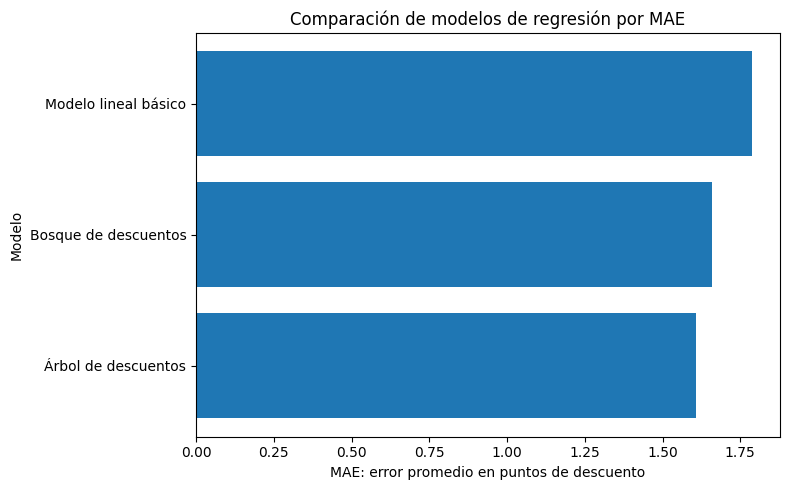

In [97]:
plt.figure(figsize=(8, 5))
plt.barh(df_resultados_regresion["modelo"], df_resultados_regresion["MAE"])
plt.title("Comparación de modelos de regresión por MAE")
plt.xlabel("MAE: error promedio en puntos de descuento")
plt.ylabel("Modelo")
plt.tight_layout()
plt.show()

## 35. Modelo de clasificación: predecir nivel VIP

La clasificación se utiliza para predecir una categoría: Plata, Oro, Platino o Diamante. En este caso se mantiene una división 80/20: 80% de los clientes para entrenamiento y 20% para prueba. El objetivo es revisar si el modelo puede generalizar con clientes que no vio durante el entrenamiento.


In [98]:
y_clasificacion = df_modelo["nivel_vip"].astype(str)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X,
    y_clasificacion,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_clasificacion
)

# Para regresión logística conviene escalar las variables.
escalador_supervisado = StandardScaler()
X_train_clf_escalado = escalador_supervisado.fit_transform(X_train_clf)
X_test_clf_escalado = escalador_supervisado.transform(X_test_clf)

modelos_clasificacion = {
    "Regresión logística VIP": LogisticRegression(max_iter=300, solver="lbfgs", random_state=RANDOM_STATE),
    "Árbol de decisión VIP": DecisionTreeClassifier(max_depth=4, min_samples_leaf=8, random_state=RANDOM_STATE),
    "Bosque de clasificación VIP": RandomForestClassifier(n_estimators=80, max_depth=6, random_state=RANDOM_STATE, n_jobs=-1)
}

resultados_clasificacion = []
predicciones_modelos = {}
modelos_entrenados = {}

for nombre, modelo in modelos_clasificacion.items():
    if "Regresión logística" in nombre:
        modelo.fit(X_train_clf_escalado, y_train_clf)
        predicciones = modelo.predict(X_test_clf_escalado)
    else:
        modelo.fit(X_train_clf, y_train_clf)
        predicciones = modelo.predict(X_test_clf)

    modelos_entrenados[nombre] = modelo
    predicciones_modelos[nombre] = predicciones

    resultados_clasificacion.append({
        "modelo": nombre,
        "accuracy": accuracy_score(y_test_clf, predicciones),
        "precision_macro": precision_score(y_test_clf, predicciones, average="macro"),
        "recall_macro": recall_score(y_test_clf, predicciones, average="macro"),
        "f1_macro": f1_score(y_test_clf, predicciones, average="macro")
    })

df_resultados_clasificacion = pd.DataFrame(resultados_clasificacion).sort_values("f1_macro", ascending=False)
display(df_resultados_clasificacion.round(4))

,modelo,accuracy,precision_macro,recall_macro,f1_macro
2,Bosque de clasificación VIP,0.92,0.92,0.83,0.86
0,Regresión logística VIP,0.90,0.82,0.78,0.80
1,Árbol de decisión VIP,0.88,0.84,0.78,0.80


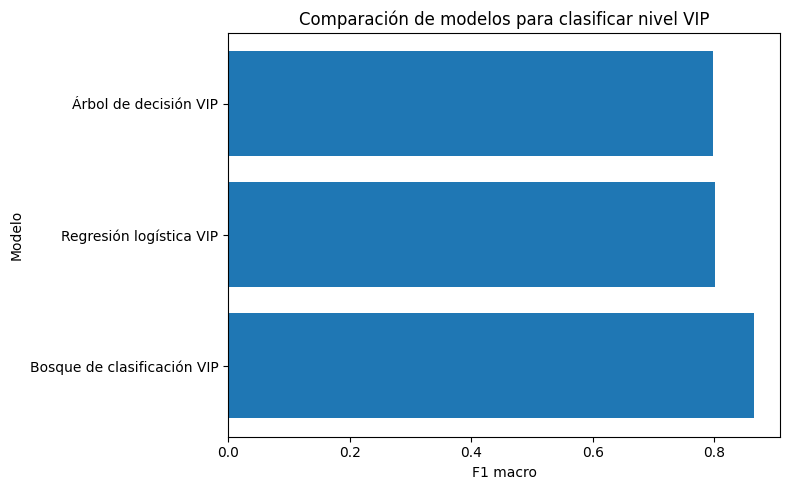

In [99]:
plt.figure(figsize=(8, 5))
plt.barh(df_resultados_clasificacion["modelo"], df_resultados_clasificacion["f1_macro"])
plt.title("Comparación de modelos para clasificar nivel VIP")
plt.xlabel("F1 macro")
plt.ylabel("Modelo")
plt.tight_layout()
plt.show()

## 36. Evaluación detallada del árbol de decisión VIP

Se revisa el árbol porque es el modelo más fácil de explicar en una presentación. No siempre será el más perfecto, pero suele ser el más interpretable.


In [100]:
arbol_vip = modelos_entrenados["Árbol de decisión VIP"]
pred_arbol = predicciones_modelos["Árbol de decisión VIP"]

print("Reporte de clasificación del Árbol de decisión VIP:")
print(classification_report(y_test_clf, pred_arbol))

Reporte de clasificación del Árbol de decisión VIP:
              precision    recall  f1-score   support

    Diamante       1.00      0.67      0.80         6
         Oro       0.86      0.68      0.76        28
       Plata       0.94      0.99      0.96        76
     Platino       0.57      0.80      0.67        10

    accuracy                           0.88       120
   macro avg       0.84      0.78      0.80       120
weighted avg       0.89      0.88      0.88       120



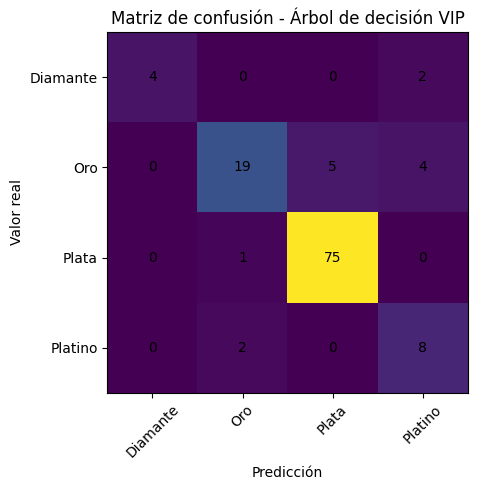

In [101]:
clases_ordenadas = sorted(y_clasificacion.unique())
matriz = confusion_matrix(y_test_clf, pred_arbol, labels=clases_ordenadas)

plt.figure(figsize=(7, 5))
plt.imshow(matriz)
plt.title("Matriz de confusión - Árbol de decisión VIP")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks(range(len(clases_ordenadas)), clases_ordenadas, rotation=45)
plt.yticks(range(len(clases_ordenadas)), clases_ordenadas)

for i in range(matriz.shape[0]):
    for j in range(matriz.shape[1]):
        plt.text(j, i, matriz[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

## 37. Visualización del árbol de decisión

El árbol de decisión es útil porque permite explicar reglas de clasificación de forma visual.

Para que el gráfico sea entendible, se cambian los nombres técnicos de las variables por nombres de negocio. Por ejemplo:

- `monto_gastado` se muestra como `Monto gastado`.
- `compras_realizadas` se muestra como `Cantidad de compras`.
- `deuda_sobre_ingreso` se muestra como `Deuda sobre ingreso`.

La idea es que el árbol no se vea como código, sino como una explicación de decisión: qué condiciones llevan a clasificar un cliente como Plata, Oro, Platino o Diamante.


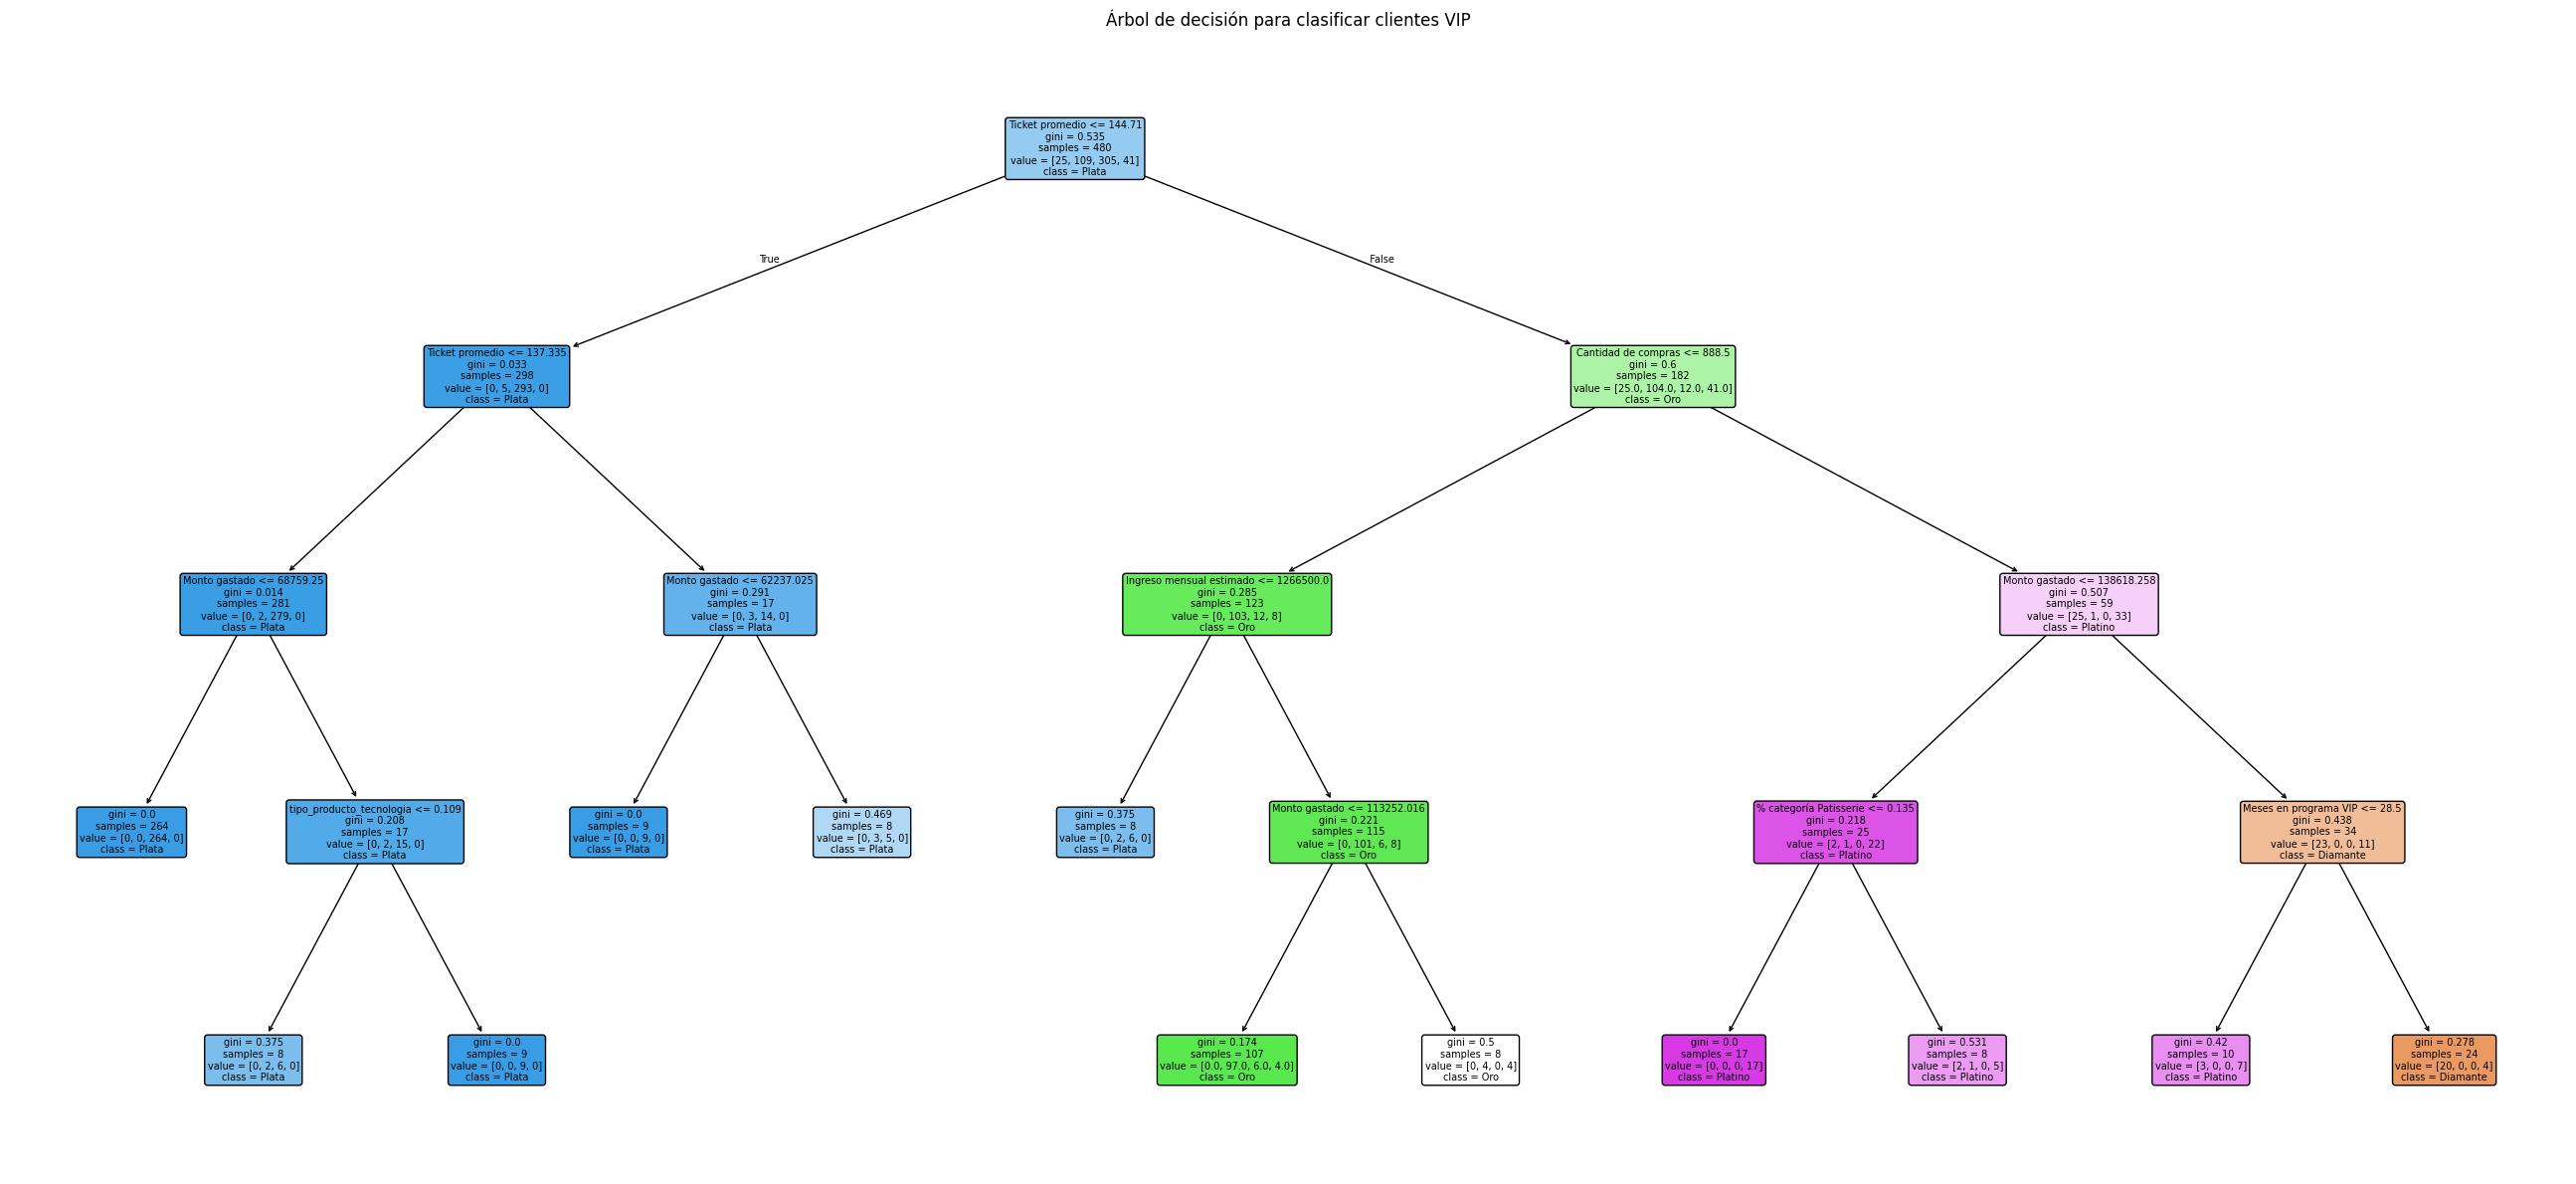

In [102]:
def nombre_legible_variable(columna):
    nombres_base = {
        "monto_gastado": "Monto gastado",
        "compras_realizadas": "Cantidad de compras",
        "ticket_promedio": "Ticket promedio",
        "ingreso_mensual": "Ingreso mensual estimado",
        "deuda_actual": "Deuda actual estimada",
        "deuda_sobre_ingreso": "Deuda sobre ingreso",
        "edad": "Edad",
        "antiguedad_cliente_meses": "Antigüedad del cliente",
        "meses_vip": "Meses en programa VIP",
        "recencia_dias": "Días desde última compra",
        "porcentaje_online": "% compras online",
        "porcentaje_descuento": "% compras con descuento",
        "productos_distintos": "Productos distintos",
        "categorias_distintas": "Categorías distintas",
        "metodos_pago_distintos": "Métodos de pago distintos"
    }

    if columna in nombres_base:
        return nombres_base[columna]
    if columna.startswith("categoria_"):
        return "% categoría " + columna.replace("categoria_", "").replace("_", " ").title()
    if columna.startswith("pago_"):
        return "% pago " + columna.replace("pago_", "").replace("_", " ").title()
    if columna.startswith("canal_"):
        return "% canal " + columna.replace("canal_", "").replace("_", " ").title()
    return columna

nombres_variables_arbol = [nombre_legible_variable(col) for col in features_supervisadas]

plt.figure(figsize=(26, 12))
plot_tree(
    arbol_vip,
    feature_names=nombres_variables_arbol,
    class_names=arbol_vip.classes_,
    filled=True,
    rounded=True,
    fontsize=7
)
plt.title("Árbol de decisión para clasificar clientes VIP")
plt.tight_layout()
plt.show()

## 38. Variables más importantes para el árbol

Esta parte ayuda a explicar qué factores pesaron más en la decisión del modelo.


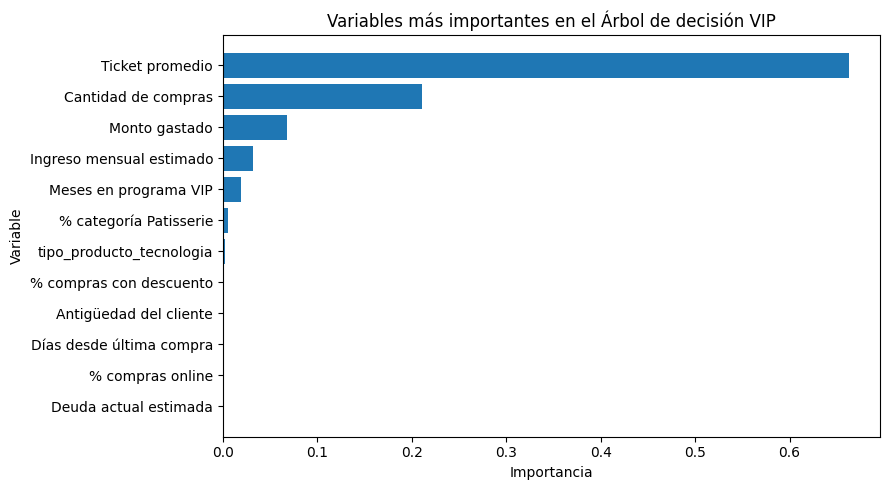

,variable,importancia
2,Ticket promedio,0.66
1,Cantidad de compras,0.21
0,Monto gastado,0.07
3,Ingreso mensual estimado,0.03
8,Meses en programa VIP,0.02
26,% categoría Patisserie,0.01
18,tipo_producto_tecnologia,0.00
4,Deuda actual estimada,0.00
7,Antigüedad del cliente,0.00
9,Días desde última compra,0.00


In [103]:
# Importancia de variables del árbol de decisión
# Esta visualización permite explicar qué variables fueron más relevantes
# para clasificar a los clientes en niveles VIP.
#
# Se muestran solo las variables con mayor importancia para evitar un gráfico saturado.

importancia_arbol = pd.DataFrame({
    "variable": nombres_variables_arbol,
    "importancia": arbol_vip.feature_importances_
}).sort_values("importancia", ascending=False)

importancia_top = importancia_arbol.head(12).sort_values("importancia", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(importancia_top["variable"], importancia_top["importancia"])
plt.title("Variables más importantes en el Árbol de decisión VIP")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

display(importancia_arbol.round(4))

## 39. Resumen final de resultados

Se reúnen los resultados principales para facilitar la presentación.


In [104]:
print("Mejor modelo de regresión según MAE:")
display(df_resultados_regresion.head(1).round(4))

print("\nMejor modelo de clasificación según F1 macro:")
display(df_resultados_clasificacion.head(1).round(4))

print("\nResultados de K-Means:")
display(df_resultados_kmeans.round(4))

print("\nCruce entre cluster y nivel VIP:")
display(tabla_cluster_vip)

Mejor modelo de regresión según MAE:


,modelo,MAE,RMSE,R2
1,Árbol de descuentos,1.61,2.76,0.78



Mejor modelo de clasificación según F1 macro:


,modelo,accuracy,precision_macro,recall_macro,f1_macro
2,Bosque de clasificación VIP,0.92,0.92,0.83,0.86



Resultados de K-Means:


,k,inertia,silhouette,lectura
0,2,"14,267.45",0.17,Mejor separación según Silhouette
1,3,"13,009.53",0.16,Alternativa evaluada
2,4,"12,148.06",0.17,Alternativa evaluada
3,5,"11,465.14",0.12,Alternativa evaluada
4,6,"10,663.76",0.14,Alternativa evaluada



Cruce entre cluster y nivel VIP:


nivel_vip,Plata,Oro,Platino,Diamante
nombre_cluster,,,,
Clientes de alto valor o prioritarios,0.03,0.58,0.24,0.15
Clientes de menor valor o por desarrollar,0.96,0.04,0.00,0.00


## 40. Conclusiones

A partir del análisis realizado se concluye lo siguiente:

1. El dataset original permite construir una base de clientes a partir de transacciones.
2. La preparación mantiene la lógica de la primera prueba: revisión de duplicados, tratamiento de nulos, conversión de fechas, normalización de texto y uso de `get_dummies`.
3. Las variables VIP fueron construidas con una lógica de negocio reproducible, incorporando gasto, frecuencia, ticket promedio, ingreso, deuda, antigüedad, meses VIP y recencia. Luego se integraron las dummies resumidas por cliente para dejar un `df_modelo` final más completo.
4. Se incorporó ruido controlado para evitar que la simulación quedara artificialmente perfecta.
5. Para clustering se evaluaron distintos valores de K usando Inertia y Silhouette.
6. `Silhouette Score` indicó que **K=2** entrega la mejor separación promedio, por lo que se dejó como modelo final no supervisado.
7. Los segmentos finales de K-Means son: **clientes de alto valor o prioritarios** y **clientes de menor valor o por desarrollar**.
8. Los niveles Plata, Oro, Platino y Diamante se mantienen como clasificación comercial supervisada mediante modelos predictivos.
9. La regresión permite predecir el descuento recomendado, mientras que el árbol de decisión permite explicar reglas de clasificación VIP.
10. PCA se utilizó solo para visualizar los clusters en dos dimensiones; no crea los grupos.


## 41. Recomendaciones de negocio

Con base en los resultados, se proponen las siguientes acciones:

- Para **clientes de alto valor o prioritarios**, aplicar campañas de fidelización, beneficios preferentes y seguimiento personalizado.
- Para **clientes de menor valor o por desarrollar**, aplicar campañas de reactivación, descuentos moderados y estrategias para aumentar frecuencia de compra.
- Mantener los niveles **Plata, Oro, Platino y Diamante** como sistema comercial supervisado para definir beneficios más específicos.
- Revisar periódicamente el modelo con datos reales para evitar que la simulación quede desactualizada.
- Usar el árbol de decisión como apoyo explicativo, porque permite mostrar reglas comprensibles para la toma de decisiones.
- Usar la regresión como apoyo para estimar descuentos de forma flexible, sin depender solo de porcentajes fijos por nivel.
